# Visualize Starmen One-Shot Longitudinal (Flow + INR)

This notebook uses the longitudinal checkpoint (`decoder + temporal flow`) from
`examples/Starmen_subset_100_id/longitudinal_cocycle_recon`.

Protocol used in the requested cells:
- Observe one scan at time 1.
- Infer one subject anchor from that observation.
- Predict other timepoints through temporal flow.
- Show GT and generated meshes side-by-side.

In [1]:
import json
import random
import re
from pathlib import Path

import numpy as np
import torch
import trimesh
import skimage.measure
import scipy.ndimage as ndi
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection, Line3DCollection

from deep_sdf import data, utils

ROOT = Path.cwd()
EXP_DIR = ROOT / "examples" / "Starmen_subset_100_id" / "longitudinal_cocycle_recon_enhanced"
SPECS = json.loads((EXP_DIR / "specs.json").read_text())

TRAIN_SPLIT_PATH = ROOT / SPECS["TrainSplit"]
TEST_SPLIT_PATH = ROOT / SPECS["TestSplit"]
TRAIN_SPLIT = json.loads(TRAIN_SPLIT_PATH.read_text())
TEST_SPLIT = json.loads(TEST_SPLIT_PATH.read_text())

GT_MESH_DIR = Path(SPECS["DataSourceMesh"])
SDF_DATA_DIR = Path(SPECS["DataSource"])

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
LATENT_SIZE = int(SPECS["CodeLength"])
FLOW_HIDDEN_DIMS = list(SPECS.get("FlowHiddenDims", [256, 256]))
TIME_MODE = str(SPECS.get("LongitudinalTimeNormalization", "subject_minmax")).lower()
CLAMP_DIST = float(SPECS.get("ClampingDistance", 0.1))
CODE_BOUND = SPECS.get("CodeBound", None)

# One-shot anchor optimization settings (aligned with train-time test eval defaults).
OBS_OPT_STEPS = int(SPECS.get("EvalTestOptimizationSteps", 1000))
OBS_OPT_SAMPLES = int(SPECS.get("EvalTestAnchorNumSamples", 16384))
OBS_OPT_LR = float(SPECS.get("EvalTestAnchorLR", 5e-3))
OBS_INIT_STD = float(SPECS.get("EvalTestAnchorInitStd", 0.01))
OBS_CODE_REG = float(SPECS.get("EvalTestAnchorCodeRegLambda", 1e-4))

# Mesh extraction settings (kept quality-oriented to avoid blobs).
GRID_RES = int(max(SPECS.get("EvalGridResolution", 256), 256))
SMOOTH_SIGMA = 0.6
ISO_CANDIDATES = [-0.003, -0.0015, 0.0, 0.0015, 0.003]
ISO_HOLDOUT_SAMPLES = 20000
KEEP_LARGEST_COMPONENT = True

# Visualization alignment + style settings.
ALIGN_FOR_VIS = True
ALIGN_MODE = "rigid"  # "rigid" or "centroid"
ALIGN_SAMPLES = 12000
ALIGN_MAX_ITERS = 20
ALIGN_TRIM_QUANTILE = 0.90

# Generated-mesh display style (to match GT mesh-like look).
GEN_DISPLAY_MAX_FACES = 200000
GT_FACE_ALPHA = 0.95
GT_EDGE_ALPHA = 0.03
GT_EDGE_WIDTH = 0.10
GEN_FACE_ALPHA = 0.98
GEN_EDGE_ALPHA = 0.35
GEN_EDGE_WIDTH = 0.14
GEN_DISPLAY_MATCH_GT_FACES = False  # display-only: keep generated surface solid (no face subsampling)
GEN_DISPLAY_FACE_RATIO_TO_GT = 1.0
GEN_DISPLAY_MIN_FACES = 1200
GEN_DISPLAY_EDGE_FACE_BUDGET = 2600  # generated wireframe overlay density
GEN_EDGE_OVERLAY_OFFSET = 0.0020  # tiny outward offset to avoid hidden overlay edges
PRED_LIGHT_GREEN = "#b8e8b8"
GEN_EDGE_COLOR = (0.22, 0.22, 0.22)  # light-black edge color for sparse generated wireframe
PRED_DISPLAY_MATCH_GT_TOPOLOGY = True  # visualization-only: render generated mesh with GT topology

# View: use x or y side view to make starmen upright.
VIEW_AXIS = "z"  # "x", "y", or "z"
INPLANE_ROT_DEG = 90.0  # counter-clockwise rotation in the displayed plane

# Optional explicit subject picks. Set to int (e.g. 5) to force.
#5, 17, 20, 28, 40, 41, 42, 44, 69, 81, 91, 100, 114, 116, 129
TARGET_TEST_SUBJECT_ID = 100 
TARGET_TRAIN_SUBJECT_ID = None

torch.manual_seed(7)
np.random.seed(7)
random.seed(7)

print("Experiment:", EXP_DIR)
print("Device:", DEVICE)
print("Train/Test split sizes:", len(TRAIN_SPLIT), len(TEST_SPLIT))
print("Time mode:", TIME_MODE)
print("View axis:", VIEW_AXIS)
print("In-plane rotation (deg):", INPLANE_ROT_DEG)
print("Alignment for visualization:", {
    "enabled": ALIGN_FOR_VIS,
    "mode": ALIGN_MODE,
    "samples": ALIGN_SAMPLES,
    "iters": ALIGN_MAX_ITERS,
    "trim_q": ALIGN_TRIM_QUANTILE,
})
print("One-shot settings:", {
    "steps": OBS_OPT_STEPS,
    "samples": OBS_OPT_SAMPLES,
    "lr": OBS_OPT_LR,
    "init_std": OBS_INIT_STD,
    "code_reg": OBS_CODE_REG,
    "code_bound": CODE_BOUND,
})
print("Mesh settings:", {
    "grid_res": GRID_RES,
    "smooth_sigma": SMOOTH_SIGMA,
    "iso_candidates": ISO_CANDIDATES,
    "keep_largest": KEEP_LARGEST_COMPONENT,
})

Experiment: /home/jakaria/INR/Deep3DComp/examples/Starmen_subset_100_id/longitudinal_cocycle_recon_enhanced
Device: cuda
Train/Test split sizes: 800 150
Time mode: subject_minmax
View axis: z
In-plane rotation (deg): 90.0
Alignment for visualization: {'enabled': True, 'mode': 'rigid', 'samples': 12000, 'iters': 20, 'trim_q': 0.9}
One-shot settings: {'steps': 1000, 'samples': 16384, 'lr': 0.005, 'init_std': 0.01, 'code_reg': 0.0001, 'code_bound': 1.0}
Mesh settings: {'grid_res': 256, 'smooth_sigma': 0.6, 'iso_candidates': [-0.003, -0.0015, 0.0, 0.0015, 0.003], 'keep_largest': True}


In [4]:
SID_RE = re.compile(r"__sid-(\d+)__")
TP_RE = re.compile(r"__tp-(\d+)__")


def base_id(name: str) -> str:
    return Path(name).stem


def parse_sid_tp(name_or_base: str):
    b = base_id(name_or_base)
    sm = SID_RE.search(b)
    tm = TP_RE.search(b)
    if sm is None or tm is None:
        raise RuntimeError(f"Cannot parse sid/tp from: {b}")
    return sm.group(1), int(tm.group(1))


def gt_mesh_path(name_or_base: str) -> Path:
    b = base_id(name_or_base)
    return GT_MESH_DIR / f"{b}.obj"


def sdf_npz_path(name_or_base: str) -> Path:
    b = base_id(name_or_base)
    return SDF_DATA_DIR / f"{b}.npz"


def load_trimesh(path: Path):
    m = trimesh.load(path, process=False)
    if isinstance(m, trimesh.Scene):
        m = trimesh.util.concatenate(tuple(g for g in m.geometry.values()))
    return m


class TemporalFlowMLP(torch.nn.Module):
    def __init__(self, latent_size, hidden_dims):
        super().__init__()
        dims = [latent_size + 2] + list(hidden_dims) + [latent_size]
        layers = []
        for i in range(len(dims) - 1):
            layers.append(torch.nn.Linear(dims[i], dims[i + 1]))
            if i < len(dims) - 2:
                layers.append(torch.nn.ReLU(inplace=True))
        self.net = torch.nn.Sequential(*layers)

    def forward(self, z, s, t):
        if s.dim() == 1:
            s = s.unsqueeze(1)
        if t.dim() == 1:
            t = t.unsqueeze(1)
        return self.net(torch.cat([z, s, t], dim=1))


def apply_temporal_flow(flow_net, z, s, t):
    return z + (t - s) * flow_net(z, s, t)


def load_decoder_and_flow(exp_dir: Path, specs: dict, checkpoint: str = "latest"):
    arch = __import__("networks." + specs["NetworkArch"], fromlist=["Decoder"])
    decoder = arch.Decoder(int(specs["CodeLength"]), **specs["NetworkSpecs"]).to(DEVICE)
    flow = TemporalFlowMLP(int(specs["CodeLength"]), list(specs.get("FlowHiddenDims", [256, 256]))).to(DEVICE)

    ckpt_path = exp_dir / "ModelParameters" / f"{checkpoint}.pth"
    payload = torch.load(ckpt_path, map_location=DEVICE)

    dec_state = {k.replace("module.", ""): v for k, v in payload["model_state_dict"].items()}
    decoder.load_state_dict(dec_state, strict=False)
    flow.load_state_dict(payload["flow_state_dict"], strict=True)

    decoder.eval()
    flow.eval()
    return decoder, flow, int(payload.get("epoch", -1))


def load_train_anchor_table(exp_dir: Path):
    p = exp_dir / "LatentCodes" / "latest.pth"
    if not p.exists():
        return None
    payload = torch.load(p, map_location="cpu")
    lat = payload.get("latent_codes", None)
    if isinstance(lat, dict):
        w = lat.get("weight", None)
    else:
        w = lat
    if w is None:
        return None
    if w.ndim == 3 and w.shape[1] == 1:
        w = w[:, 0, :]
    if w.ndim != 2:
        return None
    return w.float()


def _norm_from_mode(tp_raw, tp_min, tp_max, global_min, global_max):
    if TIME_MODE == "none":
        return float(tp_raw)
    if TIME_MODE == "global_minmax":
        return float(tp_raw - global_min) / max(float(global_max - global_min), 1e-8)
    if TIME_MODE == "subject_minmax":
        return float(tp_raw - tp_min) / max(float(tp_max - tp_min), 1e-8)
    raise ValueError(f"Unknown TIME_MODE={TIME_MODE}")


def build_split_meta(split_entries, split_name):
    subject_to_records = {}
    all_tps = []
    for name in split_entries:
        b = base_id(name)
        sid, tp = parse_sid_tp(b)
        gt_p = gt_mesh_path(b)
        sdf_p = sdf_npz_path(b)
        if not gt_p.exists() or not sdf_p.exists():
            continue
        rec = {
            "name": b,
            "sid": sid,
            "tp_raw": int(tp),
            "tp_user": int(tp + 1),
            "gt_path": gt_p,
            "sdf_path": sdf_p,
        }
        subject_to_records.setdefault(sid, []).append(rec)
        all_tps.append(int(tp))

    if not all_tps:
        raise RuntimeError(f"No valid records found for split={split_name}")

    global_min = int(min(all_tps))
    global_max = int(max(all_tps))

    for sid, recs in subject_to_records.items():
        recs.sort(key=lambda r: r["tp_raw"])
        tp_min = recs[0]["tp_raw"]
        tp_max = recs[-1]["tp_raw"]
        for r in recs:
            r["t_norm"] = _norm_from_mode(
                r["tp_raw"], tp_min, tp_max, global_min, global_max
            )

    return {
        "name": split_name,
        "subject_to_records": subject_to_records,
        "global_min": global_min,
        "global_max": global_max,
    }


def pick_subject(meta, explicit_subject_id=None, min_scans=10):
    subject_to_records = meta["subject_to_records"]
    if explicit_subject_id is not None:
        sid = str(int(explicit_subject_id)).zfill(4)
        if sid not in subject_to_records:
            raise RuntimeError(f"Requested SID={sid} not found in split={meta['name']}")
        return sid

    cands = [sid for sid, recs in subject_to_records.items() if len(recs) >= int(min_scans)]
    if not cands:
        raise RuntimeError(f"No subject with >= {min_scans} scans in split={meta['name']}")
    return sorted(cands)[0]


def record_by_user_time(records, user_time_int):
    u = int(user_time_int)
    for r in records:
        if int(r["tp_user"]) == u:
            return r
    raise RuntimeError(f"No record at user time {u}")


def user_time_to_norm(user_time, records, meta):
    # User time is 1..10 (or beyond for extrapolation). Raw tp is user_time-1.
    raw = float(user_time) - 1.0
    if TIME_MODE == "none":
        return raw
    if TIME_MODE == "global_minmax":
        return (raw - float(meta["global_min"])) / max(float(meta["global_max"] - meta["global_min"]), 1e-8)
    if TIME_MODE == "subject_minmax":
        tp_min = float(min(r["tp_raw"] for r in records))
        tp_max = float(max(r["tp_raw"] for r in records))
        return (raw - tp_min) / max(tp_max - tp_min, 1e-8)
    raise ValueError(f"Unknown TIME_MODE={TIME_MODE}")


def load_sdf_ram(record):
    sdf_data = data.read_sdf_samples_into_ram(str(record["sdf_path"]))
    sdf_data[0] = sdf_data[0][torch.randperm(sdf_data[0].shape[0])]
    sdf_data[1] = sdf_data[1][torch.randperm(sdf_data[1].shape[0])]
    return sdf_data


def optimize_anchor_from_observations(
    decoder,
    flow,
    latent_size,
    observations,
    clamp_dist,
    num_iterations,
    num_samples,
    lr,
    init_std,
    code_reg_lambda=0.0,
    code_bound=None,
):
    if len(observations) == 0:
        raise ValueError("observations cannot be empty")

    device = next(decoder.parameters()).device
    decoder_was_training = decoder.training
    flow_was_training = flow.training
    decoder.eval()
    flow.eval()

    dec_params = list(decoder.parameters())
    flow_params = list(flow.parameters())
    dec_req = [p.requires_grad for p in dec_params]
    flow_req = [p.requires_grad for p in flow_params]

    for p in dec_params:
        p.requires_grad_(False)
    for p in flow_params:
        p.requires_grad_(False)

    try:
        anchor = torch.empty(1, latent_size, device=device).normal_(0.0, float(init_std))
        anchor.requires_grad_(True)
        opt = torch.optim.Adam([anchor], lr=float(lr))
        l1 = torch.nn.L1Loss(reduction="mean")
        hist = []

        for _ in range(int(num_iterations)):
            opt.zero_grad()
            loss = 0.0
            for obs in observations:
                sdf_batch = data.unpack_sdf_samples_from_ram(obs["samples"], int(num_samples)).to(device)
                xyz = sdf_batch[:, :3]
                sdf_gt = sdf_batch[:, 3].unsqueeze(1).clamp(-float(clamp_dist), float(clamp_dist))

                t_obs = float(obs["time"])
                t = torch.full((xyz.shape[0], 1), t_obs, device=device, dtype=anchor.dtype)
                s = torch.zeros_like(t)
                z_t = apply_temporal_flow(flow, anchor.expand(xyz.shape[0], -1), s, t)
                pred = decoder(torch.cat([z_t, xyz], dim=1)).clamp(-float(clamp_dist), float(clamp_dist))
                loss = loss + l1(pred, sdf_gt)

            loss = loss / len(observations)
            if code_reg_lambda is not None and float(code_reg_lambda) > 0.0:
                loss = loss + float(code_reg_lambda) * torch.mean(anchor.pow(2))

            loss.backward()
            opt.step()

            if code_bound is not None:
                with torch.no_grad():
                    b = float(code_bound)
                    if b > 0.0:
                        n = anchor.norm(dim=1, keepdim=True)
                        anchor.mul_(torch.clamp(b / (n + 1e-12), max=1.0))

            hist.append(float(loss.detach().cpu().item()))

        return anchor.detach(), hist
    finally:
        for p, req in zip(dec_params, dec_req):
            p.requires_grad_(req)
        for p, req in zip(flow_params, flow_req):
            p.requires_grad_(req)
        if decoder_was_training:
            decoder.train()
        if flow_was_training:
            flow.train()


def keep_largest_component(mesh_obj: trimesh.Trimesh):
    parts = mesh_obj.split(only_watertight=False)
    if len(parts) <= 1:
        return mesh_obj
    parts = [p for p in parts if len(p.vertices) > 0 and len(p.faces) > 0]
    if not parts:
        return mesh_obj
    parts.sort(key=lambda m: len(m.vertices), reverse=True)
    return parts[0]


def decode_sdf_grid(decoder, latent_vec, N=256, max_batch=2**18):
    voxel_origin = [-1.0, -1.0, -1.0]
    voxel_size = 2.0 / (int(N) - 1)
    num_samples = int(N) ** 3

    overall = torch.arange(0, num_samples, dtype=torch.long)
    samples = torch.zeros(num_samples, 4, dtype=torch.float32)
    samples[:, 2] = overall % int(N)
    samples[:, 1] = (overall // int(N)) % int(N)
    samples[:, 0] = ((overall // int(N)) // int(N)) % int(N)

    samples[:, 0] = samples[:, 0] * voxel_size + voxel_origin[2]
    samples[:, 1] = samples[:, 1] * voxel_size + voxel_origin[1]
    samples[:, 2] = samples[:, 2] * voxel_size + voxel_origin[0]

    latent = latent_vec.to(next(decoder.parameters()).device)

    head = 0
    while head < num_samples:
        end = min(head + int(max_batch), num_samples)
        xyz = samples[head:end, :3].to(latent.device)
        with torch.no_grad():
            pred = utils.decode_sdf(decoder, latent, xyz).squeeze(1).detach().cpu()
        samples[head:end, 3] = pred
        head = end

    sdf_vals = samples[:, 3].reshape(int(N), int(N), int(N)).numpy()
    return sdf_vals, voxel_origin, voxel_size


def mesh_from_sdf_grid(sdf_vals, voxel_origin, voxel_size, iso_level=0.0, smooth_sigma=0.0, keep_largest=True):
    vol = sdf_vals.astype(np.float32)
    if smooth_sigma is not None and float(smooth_sigma) > 0:
        vol = ndi.gaussian_filter(vol, sigma=float(smooth_sigma))

    try:
        verts, faces, normals, _ = skimage.measure.marching_cubes(
            vol, level=float(iso_level), spacing=[voxel_size] * 3, method="lewiner"
        )
    except ValueError:
        return None

    mesh_points = np.zeros_like(verts)
    mesh_points[:, 0] = voxel_origin[0] + verts[:, 0]
    mesh_points[:, 1] = voxel_origin[1] + verts[:, 1]
    mesh_points[:, 2] = voxel_origin[2] + verts[:, 2]

    m = trimesh.Trimesh(vertices=mesh_points, faces=faces, vertex_normals=normals, process=False)
    if keep_largest:
        m = keep_largest_component(m)
    return m


def choose_iso_level(decoder, latent, sdf_data, candidates, clamp_dist=0.1, holdout_samples=20000):
    if not candidates:
        return 0.0

    device = next(decoder.parameters()).device
    pts = data.unpack_sdf_samples_from_ram(sdf_data, int(holdout_samples)).to(device)
    xyz = pts[:, :3]
    gt = pts[:, 3].clamp(-float(clamp_dist), float(clamp_dist))

    with torch.no_grad():
        pred = utils.decode_sdf(decoder, latent, xyz).squeeze(1)

    gt_sign = torch.sign(gt)
    valid = gt_sign != 0
    if valid.sum().item() == 0:
        return 0.0

    best_iso = float(candidates[0])
    best_acc = -1.0
    for iso in candidates:
        ps = torch.sign(pred - float(iso))
        acc = (ps[valid] == gt_sign[valid]).float().mean().item()
        if acc > best_acc:
            best_acc = acc
            best_iso = float(iso)
    return best_iso


def mesh_from_anchor_time(anchor, t_norm, sdf_data_for_iso=None):
    t_tensor = torch.full((1, 1), float(t_norm), device=anchor.device, dtype=anchor.dtype)
    z_t = apply_temporal_flow(flow_net, anchor, torch.zeros_like(t_tensor), t_tensor)

    iso_level = 0.0
    if sdf_data_for_iso is not None:
        iso_level = choose_iso_level(
            decoder,
            z_t,
            sdf_data_for_iso,
            ISO_CANDIDATES,
            clamp_dist=CLAMP_DIST,
            holdout_samples=ISO_HOLDOUT_SAMPLES,
        )

    sdf_vals, voxel_origin, voxel_size = decode_sdf_grid(decoder, z_t, N=GRID_RES, max_batch=int(2 ** 18))

    m = mesh_from_sdf_grid(
        sdf_vals,
        voxel_origin,
        voxel_size,
        iso_level=float(iso_level),
        smooth_sigma=float(SMOOTH_SIGMA),
        keep_largest=bool(KEEP_LARGEST_COMPONENT),
    )
    if m is None and float(iso_level) != 0.0:
        m = mesh_from_sdf_grid(
            sdf_vals,
            voxel_origin,
            voxel_size,
            iso_level=0.0,
            smooth_sigma=float(SMOOTH_SIGMA),
            keep_largest=bool(KEEP_LARGEST_COMPONENT),
        )
    if m is None:
        m = mesh_from_sdf_grid(
            sdf_vals,
            voxel_origin,
            voxel_size,
            iso_level=0.0,
            smooth_sigma=0.0,
            keep_largest=bool(KEEP_LARGEST_COMPONENT),
        )
    if m is None:
        raise RuntimeError("Mesh creation failed")

    return m, z_t.detach(), float(iso_level)


def _set_bounds(ax, mins, maxs):
    center = (mins + maxs) / 2.0
    radius = float((maxs - mins).max() / 2.0)
    if radius <= 0:
        radius = 1.0
    ax.set_xlim(center[0] - radius, center[0] + radius)
    ax.set_ylim(center[1] - radius, center[1] + radius)
    ax.set_zlim(center[2] - radius, center[2] + radius)


def _view_axis(ax):
    mode = str(VIEW_AXIS).lower()
    if mode == "x":
        ax.view_init(elev=0, azim=0)      # look through x-axis (y-z plane)
    elif mode == "y":
        ax.view_init(elev=0, azim=90)     # look through y-axis (x-z plane)
    elif mode == "z":
        ax.view_init(elev=90, azim=0)     # look through z-axis (x-y plane)
    else:
        ax.view_init(elev=20, azim=35)


def _rotation_matrix_for_axis(axis: str, degrees: float):
    th = np.deg2rad(float(degrees))
    c = np.cos(th)
    s = np.sin(th)
    a = str(axis).lower()
    if a == "x":
        return np.array([[1.0, 0.0, 0.0], [0.0, c, -s], [0.0, s, c]], dtype=np.float32)
    if a == "y":
        return np.array([[c, 0.0, s], [0.0, 1.0, 0.0], [-s, 0.0, c]], dtype=np.float32)
    if a == "z":
        return np.array([[c, -s, 0.0], [s, c, 0.0], [0.0, 0.0, 1.0]], dtype=np.float32)
    return np.eye(3, dtype=np.float32)


def _display_vertices(mesh_obj):
    verts = np.asarray(mesh_obj.vertices, dtype=np.float32)
    deg = float(INPLANE_ROT_DEG)
    if abs(deg) <= 1e-8:
        return verts
    rot = _rotation_matrix_for_axis(VIEW_AXIS, deg)
    return verts @ rot.T


def draw_mesh(ax, mesh_obj, title, color, mins=None, maxs=None):
    verts = _display_vertices(mesh_obj)
    faces = np.asarray(mesh_obj.faces)
    tris = verts[faces]
    coll = Poly3DCollection(tris, alpha=0.95)
    coll.set_facecolor(color)
    coll.set_edgecolor((0, 0, 0, 0.03))
    coll.set_linewidth(0.1)
    ax.add_collection3d(coll)

    if mins is None or maxs is None:
        mins = verts.min(axis=0)
        maxs = verts.max(axis=0)
    _set_bounds(ax, mins, maxs)

    ax.set_title(title, fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])
    _view_axis(ax)


def plot_rows_gt_pred(rows, suptitle, pred_color=PRED_LIGHT_GREEN):
    n = len(rows)
    fig = plt.figure(figsize=(12, max(4, 4 * n)))
    for i, row in enumerate(rows):
        gt_mesh = row["gt_mesh"]
        pr_mesh = row["pred_mesh"]
        label = row["label"]
        all_verts = np.concatenate([
            _display_vertices(gt_mesh),
            _display_vertices(pr_mesh),
        ], axis=0)
        mins = all_verts.min(axis=0)
        maxs = all_verts.max(axis=0)

        ax_l = fig.add_subplot(n, 2, 2 * i + 1, projection="3d")
        draw_mesh(ax_l, gt_mesh, f"{label} | GT", color="#8fb9d6", mins=mins, maxs=maxs)

        ax_r = fig.add_subplot(n, 2, 2 * i + 2, projection="3d")
        draw_mesh(ax_r, pr_mesh, f"{label} | Generated", color=pred_color, mins=mins, maxs=maxs)

    plt.suptitle(suptitle, fontsize=14)
    plt.tight_layout()
    plt.show()


def plot_three(mesh_a, title_a, mesh_b, title_b, mesh_c, title_c, suptitle):
    all_verts = np.concatenate([
        _display_vertices(mesh_a),
        _display_vertices(mesh_b),
        _display_vertices(mesh_c),
    ], axis=0)
    mins = all_verts.min(axis=0)
    maxs = all_verts.max(axis=0)

    fig = plt.figure(figsize=(16, 5))

    ax1 = fig.add_subplot(1, 3, 1, projection="3d")
    draw_mesh(ax1, mesh_a, title_a, color="#8fb9d6", mins=mins, maxs=maxs)

    ax2 = fig.add_subplot(1, 3, 2, projection="3d")
    draw_mesh(ax2, mesh_b, title_b, color="#c7d9a8", mins=mins, maxs=maxs)

    ax3 = fig.add_subplot(1, 3, 3, projection="3d")
    draw_mesh(ax3, mesh_c, title_c, color="#f2b07f", mins=mins, maxs=maxs)

    plt.suptitle(suptitle, fontsize=14)
    plt.tight_layout()
    plt.show()




# ----- Visualization alignment + generated style overrides -----
def _clone_mesh_with_vertices(mesh_obj, vertices):
    return trimesh.Trimesh(
        vertices=np.asarray(vertices, dtype=np.float32),
        faces=np.asarray(mesh_obj.faces),
        process=False,
    )


def _kabsch_rigid(src_pts, dst_pts):
    src = np.asarray(src_pts, dtype=np.float32)
    dst = np.asarray(dst_pts, dtype=np.float32)
    src_mean = src.mean(axis=0)
    dst_mean = dst.mean(axis=0)
    src0 = src - src_mean
    dst0 = dst - dst_mean
    H = src0.T @ dst0
    U, _, Vt = np.linalg.svd(H)
    R = Vt.T @ U.T
    if np.linalg.det(R) < 0:
        Vt[-1, :] *= -1
        R = Vt.T @ U.T
    t = dst_mean - src_mean @ R.T
    return R.astype(np.float32), t.astype(np.float32)


def _icp_rigid(src_pts, ref_pts, max_iters=20, trim_quantile=0.90, tol=1e-6):
    src = np.asarray(src_pts, dtype=np.float32)
    ref = np.asarray(ref_pts, dtype=np.float32)
    if src.shape[0] < 8 or ref.shape[0] < 8:
        return np.eye(3, dtype=np.float32), np.zeros(3, dtype=np.float32)

    tree = cKDTree(ref)
    R_tot = np.eye(3, dtype=np.float32)
    t_tot = np.zeros(3, dtype=np.float32)

    for _ in range(int(max_iters)):
        src_cur = src @ R_tot.T + t_tot
        d, idx = tree.query(src_cur, k=1)
        nn = ref[idx]

        if trim_quantile is not None and float(trim_quantile) < 1.0:
            thr = np.quantile(d, float(trim_quantile))
            keep = d <= thr
            if int(keep.sum()) >= 16:
                a = src_cur[keep]
                b = nn[keep]
            else:
                a = src_cur
                b = nn
        else:
            a = src_cur
            b = nn

        dR, dt = _kabsch_rigid(a, b)

        R_tot = dR @ R_tot
        t_tot = t_tot @ dR.T + dt

        if np.linalg.norm(dt) < tol and np.linalg.norm(dR - np.eye(3)) < 1e-4:
            break

    return R_tot, t_tot


def align_mesh_for_display(pred_mesh, ref_mesh):
    pv = np.asarray(pred_mesh.vertices, dtype=np.float32)
    rv = np.asarray(ref_mesh.vertices, dtype=np.float32)

    if str(ALIGN_MODE).lower() == "centroid":
        shift = rv.mean(axis=0) - pv.mean(axis=0)
        aligned_v = pv + shift
        info = {
            "mode": "centroid",
            "shift_norm": float(np.linalg.norm(shift)),
            "centroid_before": (pv.mean(axis=0) - rv.mean(axis=0)).tolist(),
            "centroid_after": (aligned_v.mean(axis=0) - rv.mean(axis=0)).tolist(),
        }
        return _clone_mesh_with_vertices(pred_mesh, aligned_v), info

    n = int(ALIGN_SAMPLES)
    p_s = trimesh.sample.sample_surface(pred_mesh, n)[0].astype(np.float32)
    r_s = trimesh.sample.sample_surface(ref_mesh, n)[0].astype(np.float32)

    R, t = _icp_rigid(
        p_s,
        r_s,
        max_iters=int(ALIGN_MAX_ITERS),
        trim_quantile=float(ALIGN_TRIM_QUANTILE),
    )
    aligned_v = pv @ R.T + t

    info = {
        "mode": "rigid",
        "shift_norm": float(np.linalg.norm(t)),
        "centroid_before": (pv.mean(axis=0) - rv.mean(axis=0)).tolist(),
        "centroid_after": (aligned_v.mean(axis=0) - rv.mean(axis=0)).tolist(),
    }
    return _clone_mesh_with_vertices(pred_mesh, aligned_v), info


def _is_pred_title(title):
    t = str(title).strip().lower()
    return t.startswith("pred") or "| generated" in t


def _is_gt_title(title):
    return str(title).strip().lower().startswith("gt") or "| gt" in str(title).strip().lower()


def _faces_for_display(mesh_obj, max_faces=None):
    faces = np.asarray(mesh_obj.faces)
    if max_faces is None:
        return faces
    m = int(max_faces)
    if m <= 0 or len(faces) <= m:
        return faces
    idx = np.linspace(0, len(faces) - 1, m, dtype=np.int64)
    return faces[idx]


def _edge_segments_for_display(mesh_obj, max_faces_for_edges=None):
    faces = _faces_for_display(mesh_obj, max_faces=max_faces_for_edges)
    if faces.size == 0:
        return np.zeros((0, 2), dtype=np.int64)

    e0 = faces[:, [0, 1]]
    e1 = faces[:, [1, 2]]
    e2 = faces[:, [2, 0]]
    edges = np.concatenate([e0, e1, e2], axis=0).astype(np.int64, copy=False)
    edges = np.sort(edges, axis=1)
    edges = np.unique(edges, axis=0)
    return edges

def _target_generated_faces(ref_mesh=None):
    max_faces = int(GEN_DISPLAY_MAX_FACES)
    if ref_mesh is None or not bool(GEN_DISPLAY_MATCH_GT_FACES):
        return max_faces

    ref_faces = int(len(np.asarray(ref_mesh.faces)))
    ratio = float(GEN_DISPLAY_FACE_RATIO_TO_GT)
    target = int(round(ratio * ref_faces))
    target = max(int(GEN_DISPLAY_MIN_FACES), target)
    target = min(max_faces, target)
    return int(target)


def _mesh_style(is_generated, base_color, ref_mesh=None):
    if is_generated:
        return {
            "color": base_color,
            "max_faces": None,
            "face_alpha": float(GEN_FACE_ALPHA),
            "edge_alpha": 0.0,
            "edge_width": 0.0,
            "edge_color": tuple(float(x) for x in GEN_EDGE_COLOR),
            "overlay_edge_alpha": float(GEN_EDGE_ALPHA),
            "overlay_edge_width": float(GEN_EDGE_WIDTH),
            "overlay_edge_face_budget": int(GEN_DISPLAY_EDGE_FACE_BUDGET),
            "overlay_edge_offset": float(GEN_EDGE_OVERLAY_OFFSET),
        }
    return {
        "color": base_color,
        "max_faces": None,
        "face_alpha": float(GT_FACE_ALPHA),
        "edge_alpha": float(GT_EDGE_ALPHA),
        "edge_width": float(GT_EDGE_WIDTH),
        "edge_color": (0.0, 0.0, 0.0),
        "overlay_edge_alpha": 0.0,
        "overlay_edge_width": 0.0,
        "overlay_edge_face_budget": None,
        "overlay_edge_offset": 0.0,
    }

def draw_mesh(
    ax,
    mesh_obj,
    title,
    color,
    mins=None,
    maxs=None,
    max_faces=None,
    face_alpha=0.95,
    edge_alpha=0.03,
    edge_width=0.1,
    edge_color=(0.0, 0.0, 0.0),
    overlay_edge_alpha=0.0,
    overlay_edge_width=0.0,
    overlay_edge_face_budget=None,
    overlay_edge_offset=0.0,
):
    verts = _display_vertices(mesh_obj)
    faces = _faces_for_display(mesh_obj, max_faces=max_faces)
    tris = verts[faces]
    coll = Poly3DCollection(tris, alpha=float(face_alpha))
    coll.set_facecolor(color)
    ec = tuple(float(v) for v in edge_color)
    coll.set_edgecolor((ec[0], ec[1], ec[2], float(edge_alpha)))
    coll.set_linewidth(float(edge_width))
    ax.add_collection3d(coll)

    if overlay_edge_alpha is not None and float(overlay_edge_alpha) > 0.0 and overlay_edge_width is not None and float(overlay_edge_width) > 0.0:
        edge_pairs = _edge_segments_for_display(mesh_obj, max_faces_for_edges=overlay_edge_face_budget)
        if edge_pairs.size > 0:
            edge_verts = verts
            if overlay_edge_offset is not None and float(overlay_edge_offset) > 0.0:
                ctr = verts.mean(axis=0, keepdims=True)
                dv = verts - ctr
                dn = np.linalg.norm(dv, axis=1, keepdims=True)
                edge_verts = verts + (dv / np.maximum(dn, 1e-8)) * float(overlay_edge_offset)

            segments = np.stack([edge_verts[edge_pairs[:, 0]], edge_verts[edge_pairs[:, 1]]], axis=1)
            line_coll = Line3DCollection(
                segments,
                colors=[(ec[0], ec[1], ec[2], float(overlay_edge_alpha))],
                linewidths=float(overlay_edge_width),
            )
            ax.add_collection3d(line_coll)

    if mins is None or maxs is None:
        mins = verts.min(axis=0)
        maxs = verts.max(axis=0)
    _set_bounds(ax, mins, maxs)

    ax.set_title(title, fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])
    _view_axis(ax)

def _project_to_ref_topology(pred_mesh, ref_mesh):
    ref_v = np.asarray(ref_mesh.vertices, dtype=np.float32)
    ref_f = np.asarray(ref_mesh.faces)

    try:
        proj_pts, _, _ = trimesh.proximity.closest_point(pred_mesh, ref_v)
        proj_pts = np.asarray(proj_pts, dtype=np.float32)
        if proj_pts.shape != ref_v.shape:
            raise RuntimeError("closest_point returned unexpected shape")
    except Exception:
        # Fallback when trimesh proximity backend is unavailable.
        pv = np.asarray(pred_mesh.vertices, dtype=np.float32)
        if pv.shape[0] == 0:
            return pred_mesh
        nn = cKDTree(pv)
        _, idx = nn.query(ref_v, k=1)
        proj_pts = pv[np.asarray(idx, dtype=np.int64)]

    return trimesh.Trimesh(vertices=proj_pts, faces=ref_f, process=False)


def _prepare_pred_for_display(pred_mesh, ref_mesh):
    out = pred_mesh
    align_info = None

    if bool(ALIGN_FOR_VIS):
        out, align_info = align_mesh_for_display(out, ref_mesh)

    if bool(PRED_DISPLAY_MATCH_GT_TOPOLOGY):
        out = _project_to_ref_topology(out, ref_mesh)

    return out, align_info


def _align_for_pair(gt_mesh, pred_mesh):
    return _prepare_pred_for_display(pred_mesh, gt_mesh)


def plot_rows_gt_pred(rows, suptitle, pred_color=PRED_LIGHT_GREEN):
    n = len(rows)
    fig = plt.figure(figsize=(12, max(4, 4 * n)))
    for i, row in enumerate(rows):
        gt_mesh = row["gt_mesh"]
        pr_mesh = row["pred_mesh"]
        label = row["label"]

        pr_disp, align_info = _align_for_pair(gt_mesh, pr_mesh)

        all_verts = np.concatenate([
            _display_vertices(gt_mesh),
            _display_vertices(pr_disp),
        ], axis=0)
        mins = all_verts.min(axis=0)
        maxs = all_verts.max(axis=0)

        gt_style = _mesh_style(False, "#8fb9d6")
        pr_style = _mesh_style(True, pred_color, ref_mesh=gt_mesh)

        ax_l = fig.add_subplot(n, 2, 2 * i + 1, projection="3d")
        draw_mesh(
            ax_l,
            gt_mesh,
            f"{label} | GT",
            mins=mins,
            maxs=maxs,
            **gt_style,
        )

        right_title = f"{label} | Generated"
        if align_info is not None:
            right_title += " (aligned)"
        ax_r = fig.add_subplot(n, 2, 2 * i + 2, projection="3d")
        draw_mesh(
            ax_r,
            pr_disp,
            right_title,
            mins=mins,
            maxs=maxs,
            **pr_style,
        )

    plt.suptitle(suptitle, fontsize=14)
    plt.tight_layout()
    plt.show()


def plot_three(mesh_a, title_a, mesh_b, title_b, mesh_c, title_c, suptitle):
    a, b, c = mesh_a, mesh_b, mesh_c

    if _is_pred_title(title_b):
        ref = mesh_a if _is_gt_title(title_a) else mesh_c
        b, _ = _prepare_pred_for_display(mesh_b, ref)
    if _is_pred_title(title_c):
        ref = mesh_b if _is_gt_title(title_b) else mesh_a
        c, _ = _prepare_pred_for_display(mesh_c, ref)
    if _is_pred_title(title_a):
        ref = mesh_b if _is_gt_title(title_b) else mesh_c
        a, _ = _prepare_pred_for_display(mesh_a, ref)

    all_verts = np.concatenate([
        _display_vertices(a),
        _display_vertices(b),
        _display_vertices(c),
    ], axis=0)
    mins = all_verts.min(axis=0)
    maxs = all_verts.max(axis=0)

    fig = plt.figure(figsize=(16, 5))

    ref_a = mesh_b if _is_gt_title(title_b) else mesh_c
    ref_b = mesh_a if _is_gt_title(title_a) else mesh_c
    ref_c = mesh_b if _is_gt_title(title_b) else mesh_a

    color_a = PRED_LIGHT_GREEN if _is_pred_title(title_a) else "#8fb9d6"
    color_b = PRED_LIGHT_GREEN if _is_pred_title(title_b) else "#c7d9a8"
    color_c = PRED_LIGHT_GREEN if _is_pred_title(title_c) else "#f2b07f"

    style_a = _mesh_style(_is_pred_title(title_a), color_a, ref_mesh=ref_a if _is_pred_title(title_a) else None)
    style_b = _mesh_style(_is_pred_title(title_b), color_b, ref_mesh=ref_b if _is_pred_title(title_b) else None)
    style_c = _mesh_style(_is_pred_title(title_c), color_c, ref_mesh=ref_c if _is_pred_title(title_c) else None)

    ax1 = fig.add_subplot(1, 3, 1, projection="3d")
    draw_mesh(ax1, a, title_a, mins=mins, maxs=maxs, **style_a)

    ax2 = fig.add_subplot(1, 3, 2, projection="3d")
    draw_mesh(ax2, b, title_b, mins=mins, maxs=maxs, **style_b)

    ax3 = fig.add_subplot(1, 3, 3, projection="3d")
    draw_mesh(ax3, c, title_c, mins=mins, maxs=maxs, **style_c)

    plt.suptitle(suptitle, fontsize=14)
    plt.tight_layout()
    plt.show()
# ----- End visualization overrides -----

decoder, flow_net, MODEL_EPOCH = load_decoder_and_flow(EXP_DIR, SPECS, checkpoint="latest")
TRAIN_ANCHOR_TABLE = load_train_anchor_table(EXP_DIR)
TRAIN_META = build_split_meta(TRAIN_SPLIT, split_name="train")
TEST_META = build_split_meta(TEST_SPLIT, split_name="test")

print("Loaded checkpoint epoch:", MODEL_EPOCH)
print("Train anchors table:", None if TRAIN_ANCHOR_TABLE is None else tuple(TRAIN_ANCHOR_TABLE.shape))
print("Train subjects:", len(TRAIN_META["subject_to_records"]), "Test subjects:", len(TEST_META["subject_to_records"]))

Loaded checkpoint epoch: 2000
Train anchors table: (80, 256)
Train subjects: 80 Test subjects: 15


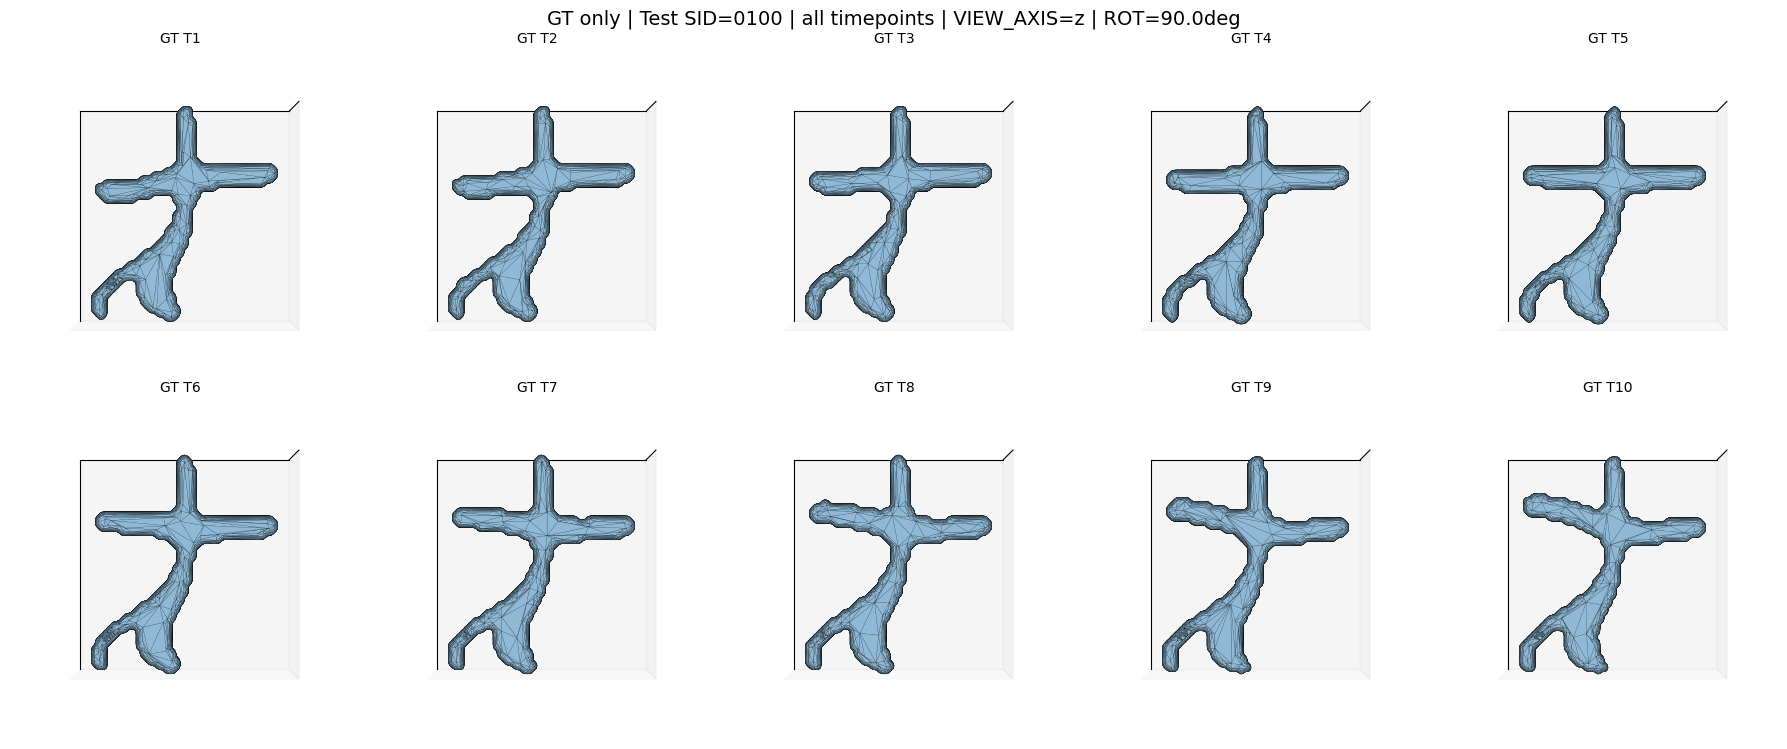

Displayed 10 GT meshes for SID 0100


In [5]:
# View-angle check (GT only): show all GT timepoints for one test subject.
# This cell can run without Cell 1; it auto-picks a test subject if needed.
if "TEST_META" not in globals():
    raise RuntimeError("Run the first two setup/helper cells first.")

# Always repick from TARGET_TEST_SUBJECT_ID so stale notebook state does not keep an old SID.
TEST_SID = pick_subject(TEST_META, explicit_subject_id=TARGET_TEST_SUBJECT_ID, min_scans=10)
TEST_RECORDS = TEST_META["subject_to_records"][TEST_SID]

records = sorted(TEST_RECORDS, key=lambda r: int(r["tp_user"]))
gt_meshes = [load_trimesh(r["gt_path"]) for r in records]

all_verts = np.concatenate([_display_vertices(m) for m in gt_meshes], axis=0)
mins = all_verts.min(axis=0)
maxs = all_verts.max(axis=0)

n = len(records)
cols = 5
rows = int(np.ceil(n / cols))
fig = plt.figure(figsize=(3.6 * cols, 3.8 * rows))

for i, (rec, m) in enumerate(zip(records, gt_meshes), start=1):
    ax = fig.add_subplot(rows, cols, i, projection="3d")
    draw_mesh(
        ax,
        m,
        f"GT T{rec['tp_user']}",
        color="#8fb9d6",
        mins=mins,
        maxs=maxs,
    )

# Hide any unused panels.
for j in range(n + 1, rows * cols + 1):
    ax = fig.add_subplot(rows, cols, j, projection="3d")
    ax.axis("off")

plt.suptitle(
    f"GT only | Test SID={TEST_SID} | all timepoints | VIEW_AXIS={VIEW_AXIS} | ROT={INPLANE_ROT_DEG}deg",
    fontsize=14,
)
plt.tight_layout()
plt.show()

print("Displayed", n, "GT meshes for SID", TEST_SID)


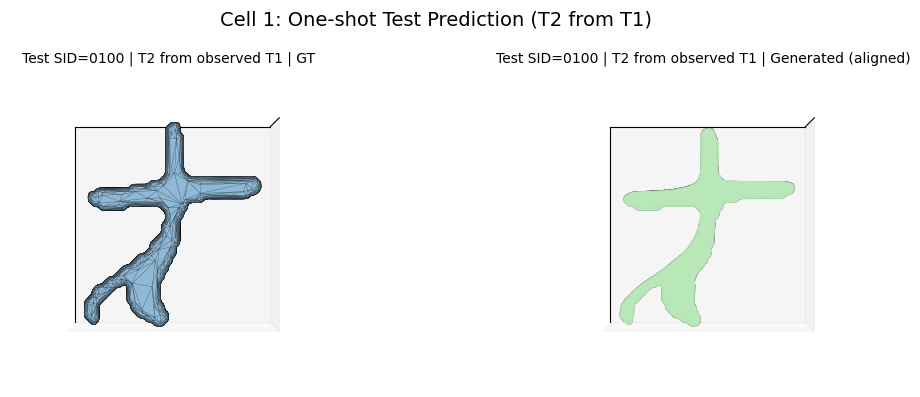

Test SID: 0100
Observed: starman3d__ds-output_random_noacc__sid-0100__tp-00__age-m006p40__scan-SimulatedData__Reconstruction__starman__subject_s100__tp_0
Predicted target: starman3d__ds-output_random_noacc__sid-0100__tp-01__age-m005p40__scan-SimulatedData__Reconstruction__starman__subject_s100__tp_1
Anchor optimization final loss: 0.00147400819696486
Iso level used for T2: 0.0


In [6]:
# Cell 1: One-shot test subject. Given starmen at time 1, generate time 2 and show GT side-by-side.
TEST_SID = pick_subject(TEST_META, explicit_subject_id=TARGET_TEST_SUBJECT_ID, min_scans=10)
TEST_RECORDS = TEST_META["subject_to_records"][TEST_SID]

obs_rec_t1 = record_by_user_time(TEST_RECORDS, 1)
tgt_rec_t2 = record_by_user_time(TEST_RECORDS, 2)

obs_sdf_t1 = load_sdf_ram(obs_rec_t1)
obs_list = [{"samples": obs_sdf_t1, "time": float(obs_rec_t1["t_norm"])}]

TEST_ANCHOR_FROM_T1, TEST_ANCHOR_LOSS_HIST = optimize_anchor_from_observations(
    decoder,
    flow_net,
    LATENT_SIZE,
    obs_list,
    clamp_dist=CLAMP_DIST,
    num_iterations=OBS_OPT_STEPS,
    num_samples=OBS_OPT_SAMPLES,
    lr=OBS_OPT_LR,
    init_std=OBS_INIT_STD,
    code_reg_lambda=OBS_CODE_REG,
    code_bound=CODE_BOUND,
)

sdf_t2_for_iso = load_sdf_ram(tgt_rec_t2)
pred_mesh_t2, pred_lat_t2, iso_t2 = mesh_from_anchor_time(
    TEST_ANCHOR_FROM_T1,
    float(tgt_rec_t2["t_norm"]),
    sdf_data_for_iso=sdf_t2_for_iso,
)
gt_mesh_t2 = load_trimesh(tgt_rec_t2["gt_path"])

plot_rows_gt_pred(
    [{
        "gt_mesh": gt_mesh_t2,
        "pred_mesh": pred_mesh_t2,
        "label": f"Test SID={TEST_SID} | T2 from observed T1",
    }],
    suptitle="Cell 1: One-shot Test Prediction (T2 from T1)",
)

print("Test SID:", TEST_SID)
print("Observed:", obs_rec_t1["name"])
print("Predicted target:", tgt_rec_t2["name"])
print("Anchor optimization final loss:", TEST_ANCHOR_LOSS_HIST[-1] if TEST_ANCHOR_LOSS_HIST else None)
print("Iso level used for T2:", iso_t2)

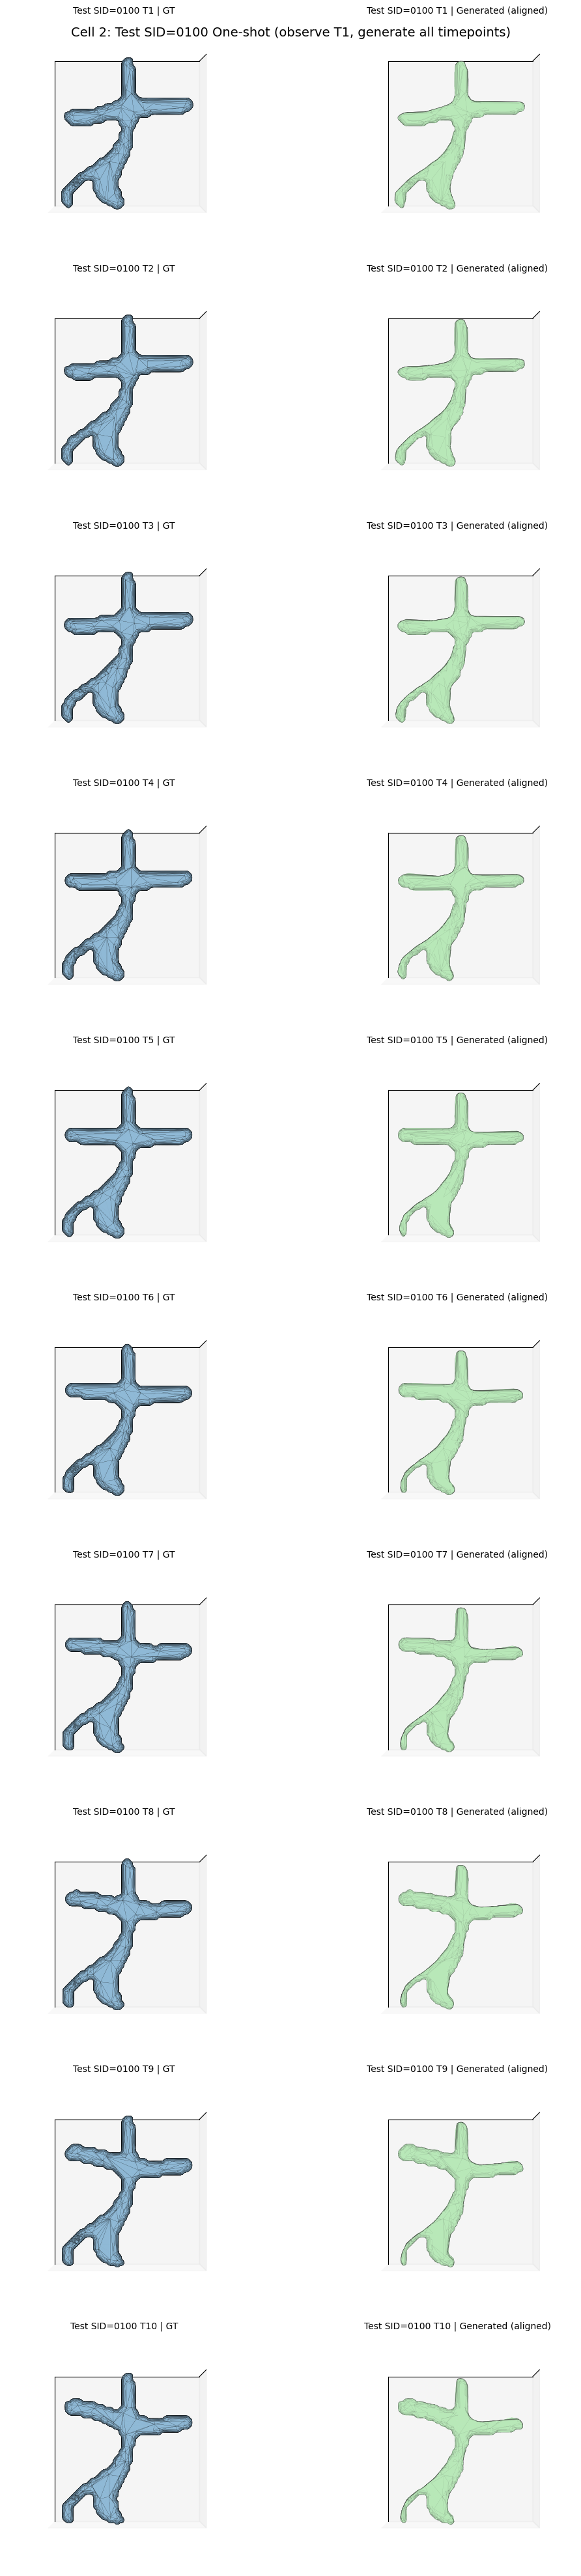

Generated rows: 10
Iso per timepoint: {1: 0.0, 2: 0.0, 3: 0.0, 4: 0.0, 5: 0.0, 6: 0.0, 7: 0.0, 8: 0.0, 9: 0.0, 10: 0.0}


In [7]:
# Cell 2: Same test subject. Given time 1, generate all 10 timepoints and show GT vs generated side-by-side.
if "TEST_ANCHOR_FROM_T1" not in globals():
    raise RuntimeError("Run Cell 1 first.")

rows = []
iso_levels = {}
for rec in TEST_RECORDS:
    sdf_for_iso = load_sdf_ram(rec)
    pred_mesh, _, iso_val = mesh_from_anchor_time(
        TEST_ANCHOR_FROM_T1,
        float(rec["t_norm"]),
        sdf_data_for_iso=sdf_for_iso,
    )
    gt_mesh = load_trimesh(rec["gt_path"])
    rows.append({
        "gt_mesh": gt_mesh,
        "pred_mesh": pred_mesh,
        "label": f"Test SID={TEST_SID} T{rec['tp_user']}",
    })
    iso_levels[int(rec["tp_user"])] = float(iso_val)

plot_rows_gt_pred(
    rows,
    suptitle=f"Cell 2: Test SID={TEST_SID} One-shot (observe T1, generate all timepoints)",
)

print("Generated rows:", len(rows))
print("Iso per timepoint:", iso_levels)

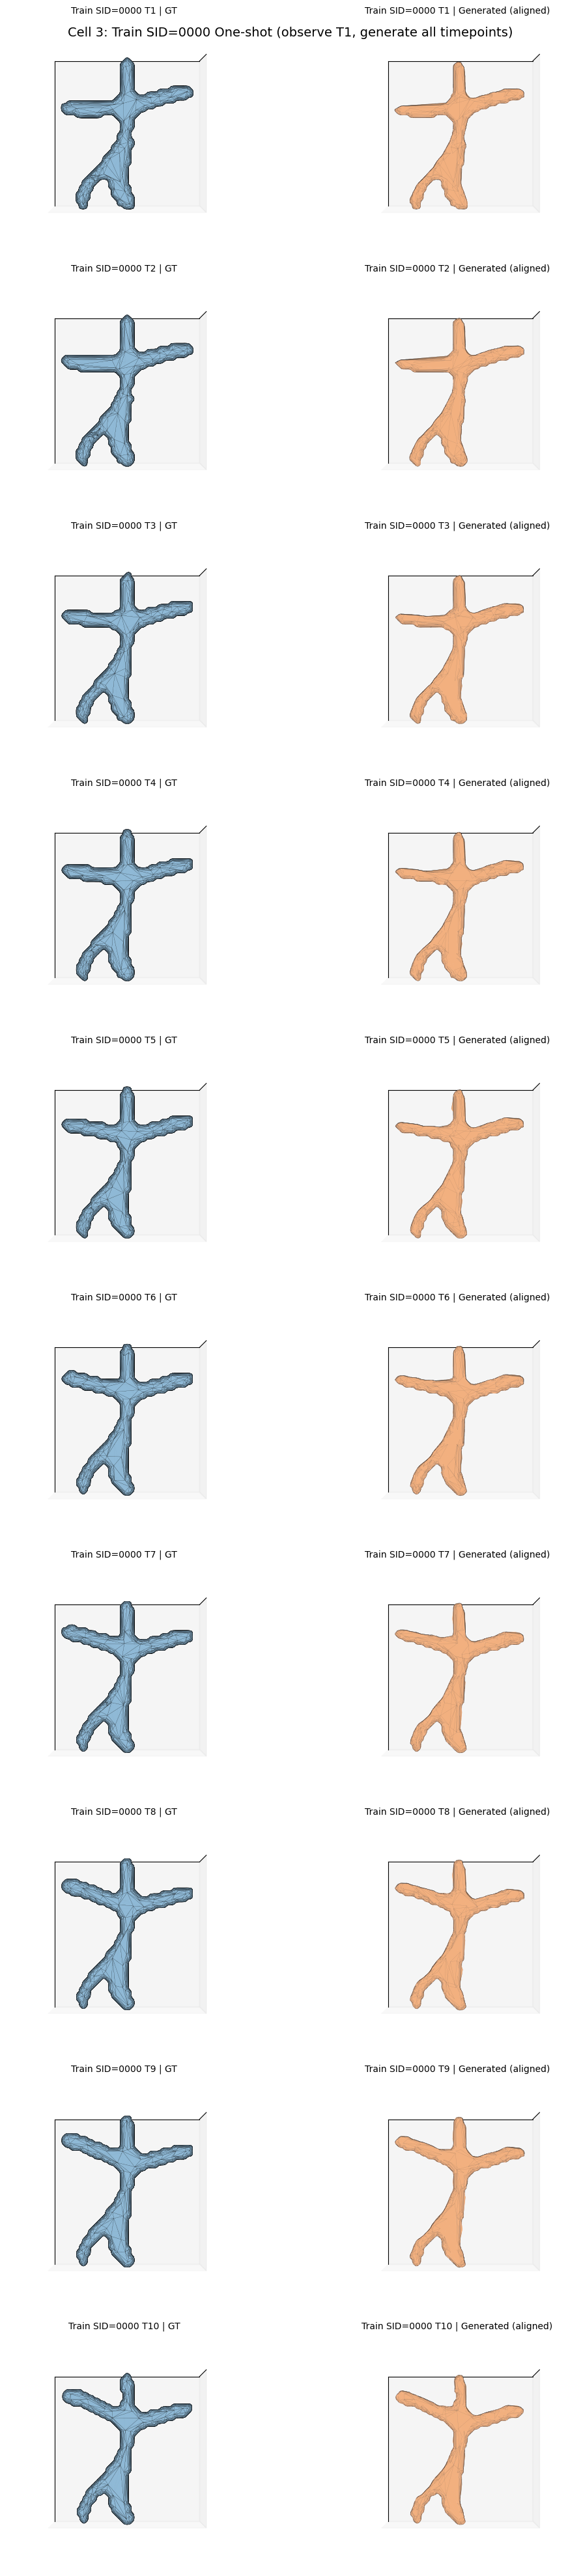

Train SID: 0000
Observed: starman3d__ds-output_random_noacc__sid-0000__tp-00__age-m004p29__scan-SimulatedData__Reconstruction__starman__subject_s0__tp_0
Anchor optimization final loss: 0.0007283593295142055
Iso per timepoint: {1: 0.0, 2: 0.0, 3: 0.0, 4: 0.0, 5: 0.0, 6: 0.0, 7: 0.0, 8: 0.0, 9: 0.0, 10: 0.0}


In [8]:
# Cell 3: Train subject one-shot. Observe train time 1, generate all other timepoints, show GT vs generated.
TRAIN_SID = pick_subject(TRAIN_META, explicit_subject_id=TARGET_TRAIN_SUBJECT_ID, min_scans=10)
TRAIN_RECORDS = TRAIN_META["subject_to_records"][TRAIN_SID]

obs_train_t1 = record_by_user_time(TRAIN_RECORDS, 1)
obs_train_sdf = load_sdf_ram(obs_train_t1)
obs_train_list = [{"samples": obs_train_sdf, "time": float(obs_train_t1["t_norm"])}]

TRAIN_ANCHOR_FROM_T1, TRAIN_ANCHOR_LOSS_HIST = optimize_anchor_from_observations(
    decoder,
    flow_net,
    LATENT_SIZE,
    obs_train_list,
    clamp_dist=CLAMP_DIST,
    num_iterations=OBS_OPT_STEPS,
    num_samples=OBS_OPT_SAMPLES,
    lr=OBS_OPT_LR,
    init_std=OBS_INIT_STD,
    code_reg_lambda=OBS_CODE_REG,
    code_bound=CODE_BOUND,
)

rows = []
iso_levels = {}
for rec in TRAIN_RECORDS:
    sdf_for_iso = load_sdf_ram(rec)
    pred_mesh, _, iso_val = mesh_from_anchor_time(
        TRAIN_ANCHOR_FROM_T1,
        float(rec["t_norm"]),
        sdf_data_for_iso=sdf_for_iso,
    )
    gt_mesh = load_trimesh(rec["gt_path"])
    rows.append({
        "gt_mesh": gt_mesh,
        "pred_mesh": pred_mesh,
        "label": f"Train SID={TRAIN_SID} T{rec['tp_user']}",
    })
    iso_levels[int(rec["tp_user"])] = float(iso_val)

plot_rows_gt_pred(
    rows,
    suptitle=f"Cell 3: Train SID={TRAIN_SID} One-shot (observe T1, generate all timepoints)",
    pred_color="#f2b07f",
)

print("Train SID:", TRAIN_SID)
print("Observed:", obs_train_t1["name"])
print("Anchor optimization final loss:", TRAIN_ANCHOR_LOSS_HIST[-1] if TRAIN_ANCHOR_LOSS_HIST else None)
print("Iso per timepoint:", iso_levels)

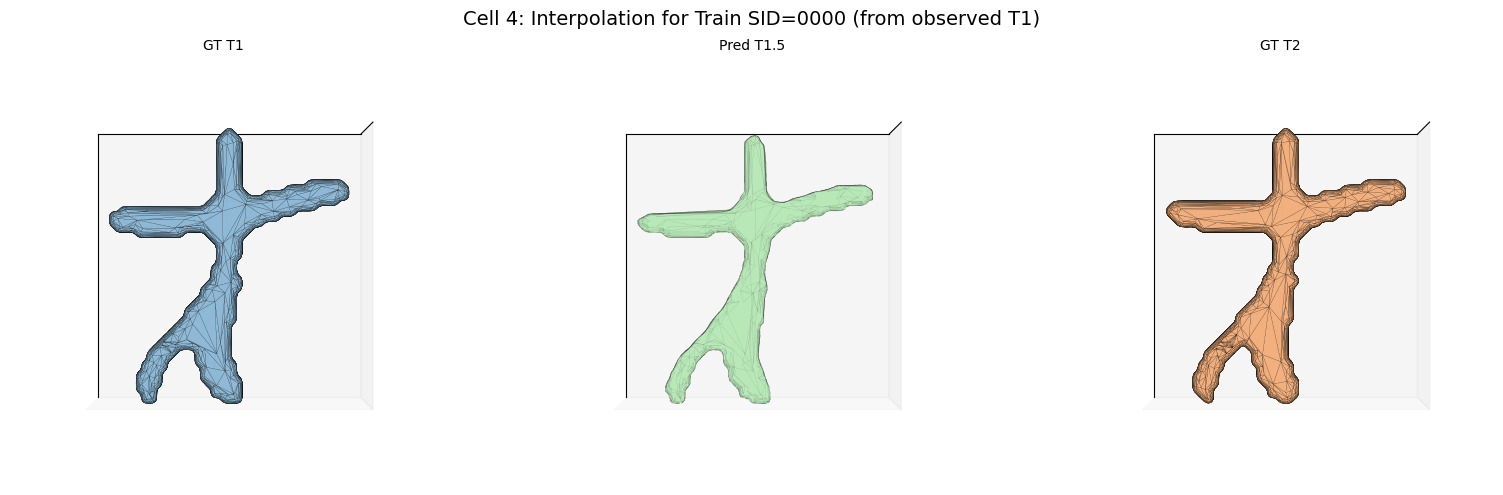

Train SID: 0000
Interpolation user time: 1.5
Interpolation normalized time: 0.05555555555555555
Iso level used: 0.0


In [9]:
# Cell 4: Train interpolation. Predict at time 1.5 from observed train time 1. Show GT time 1 and GT time 2.
if "TRAIN_ANCHOR_FROM_T1" not in globals() or "TRAIN_RECORDS" not in globals() or "TRAIN_META" not in globals():
    raise RuntimeError("Run Cell 3 first.")

train_gt_t1_rec = record_by_user_time(TRAIN_RECORDS, 1)
train_gt_t2_rec = record_by_user_time(TRAIN_RECORDS, 2)

TRAIN_T_INTERP_USER = 1.5
TRAIN_T_INTERP_NORM = user_time_to_norm(TRAIN_T_INTERP_USER, TRAIN_RECORDS, TRAIN_META)

# No exact GT SDF at 1.5; use nearest train timepoint for iso-level calibration.
train_nearest_rec = min(TRAIN_RECORDS, key=lambda r: abs(float(r["tp_user"]) - float(TRAIN_T_INTERP_USER)))
train_nearest_sdf = load_sdf_ram(train_nearest_rec)

pred_train_interp_mesh, _, train_iso_interp = mesh_from_anchor_time(
    TRAIN_ANCHOR_FROM_T1,
    float(TRAIN_T_INTERP_NORM),
    sdf_data_for_iso=train_nearest_sdf,
)

gt_train_mesh_t1 = load_trimesh(train_gt_t1_rec["gt_path"])
gt_train_mesh_t2 = load_trimesh(train_gt_t2_rec["gt_path"])

plot_three(
    gt_train_mesh_t1,
    "GT T1",
    pred_train_interp_mesh,
    f"Pred T{TRAIN_T_INTERP_USER}",
    gt_train_mesh_t2,
    "GT T2",
    suptitle=f"Cell 4: Interpolation for Train SID={TRAIN_SID} (from observed T1)",
)

print("Train SID:", TRAIN_SID)
print("Interpolation user time:", TRAIN_T_INTERP_USER)
print("Interpolation normalized time:", TRAIN_T_INTERP_NORM)
print("Iso level used:", train_iso_interp)


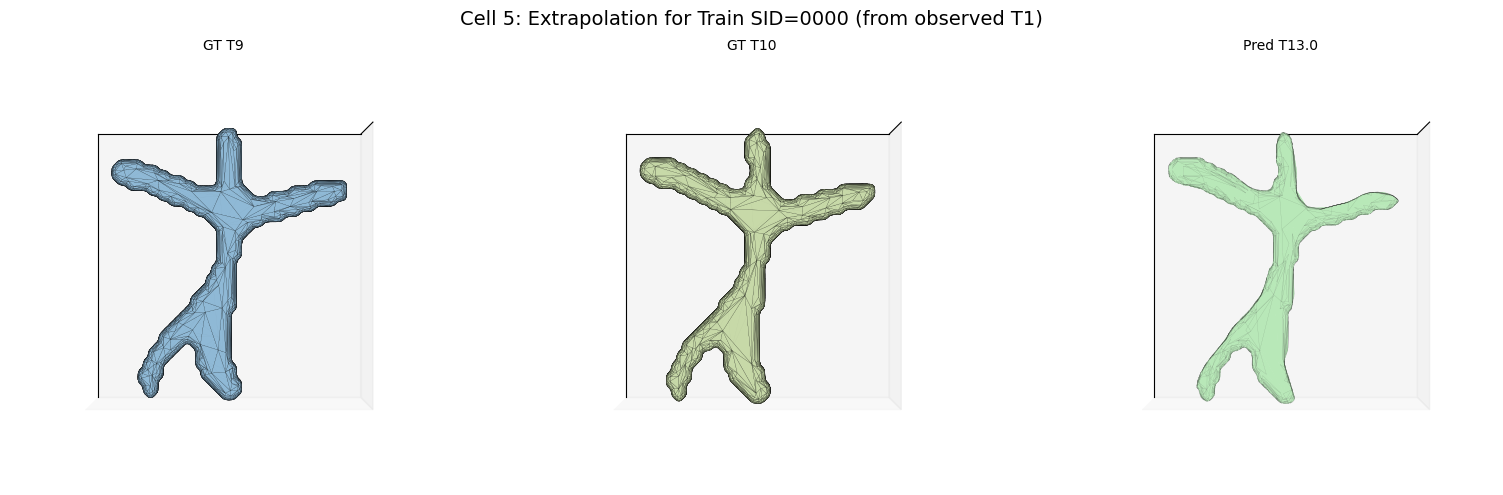

Train SID: 0000
Extrapolation user time: 13.0
Extrapolation normalized time: 1.3333333333333333
Iso level used: 0.0


In [10]:
# Cell 5: Train extrapolation. Predict at time 12 from observed train time 1. Show GT time 9 and GT time 10.
if "TRAIN_ANCHOR_FROM_T1" not in globals() or "TRAIN_RECORDS" not in globals() or "TRAIN_META" not in globals():
    raise RuntimeError("Run Cell 3 first.")

train_gt_t9_rec = record_by_user_time(TRAIN_RECORDS, 9)
train_gt_t10_rec = record_by_user_time(TRAIN_RECORDS, 10)

TRAIN_T_EXTRA_USER = 13.0
TRAIN_T_EXTRA_NORM = user_time_to_norm(TRAIN_T_EXTRA_USER, TRAIN_RECORDS, TRAIN_META)

# No GT SDF at time 12; use latest train timepoint for iso-level calibration.
train_latest_sdf = load_sdf_ram(train_gt_t10_rec)

pred_train_extra_mesh, _, train_iso_extra = mesh_from_anchor_time(
    TRAIN_ANCHOR_FROM_T1,
    float(TRAIN_T_EXTRA_NORM),
    sdf_data_for_iso=train_latest_sdf,
)

gt_train_mesh_t9 = load_trimesh(train_gt_t9_rec["gt_path"])
gt_train_mesh_t10 = load_trimesh(train_gt_t10_rec["gt_path"])

plot_three(
    gt_train_mesh_t9,
    "GT T9",
    gt_train_mesh_t10,
    "GT T10",
    pred_train_extra_mesh,
    f"Pred T{TRAIN_T_EXTRA_USER}",
    suptitle=f"Cell 5: Extrapolation for Train SID={TRAIN_SID} (from observed T1)",
)

print("Train SID:", TRAIN_SID)
print("Extrapolation user time:", TRAIN_T_EXTRA_USER)
print("Extrapolation normalized time:", TRAIN_T_EXTRA_NORM)
print("Iso level used:", train_iso_extra)


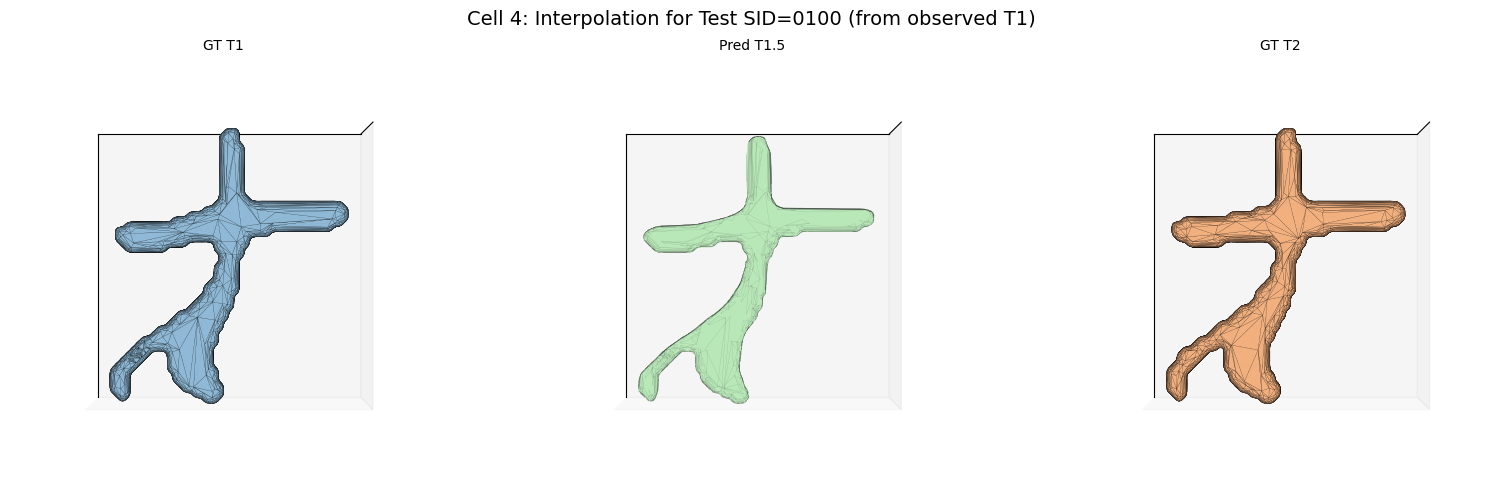

Interpolation user time: 1.5
Interpolation normalized time: 0.05555555555555555
Iso level used: 0.0


In [11]:
# Cell 4: Interpolation. Predict at time 1.5 from observed time 1. Show GT time 1 and GT time 2.
if "TEST_ANCHOR_FROM_T1" not in globals() or "TEST_RECORDS" not in globals():
    raise RuntimeError("Run Cell 1 first.")

gt_t1_rec = record_by_user_time(TEST_RECORDS, 1)
gt_t2_rec = record_by_user_time(TEST_RECORDS, 2)

T_INTERP_USER = 1.5
T_INTERP_NORM = user_time_to_norm(T_INTERP_USER, TEST_RECORDS, TEST_META)

# For interpolation there is no exact GT SDF; use nearest GT timepoint for iso-level calibration.
nearest_rec = min(TEST_RECORDS, key=lambda r: abs(float(r["tp_user"]) - float(T_INTERP_USER)))
nearest_sdf = load_sdf_ram(nearest_rec)

pred_interp_mesh, _, iso_interp = mesh_from_anchor_time(
    TEST_ANCHOR_FROM_T1,
    float(T_INTERP_NORM),
    sdf_data_for_iso=nearest_sdf,
)

gt_mesh_t1 = load_trimesh(gt_t1_rec["gt_path"])
gt_mesh_t2 = load_trimesh(gt_t2_rec["gt_path"])

plot_three(
    gt_mesh_t1,
    f"GT T1",
    pred_interp_mesh,
    f"Pred T{T_INTERP_USER}",
    gt_mesh_t2,
    f"GT T2",
    suptitle=f"Cell 4: Interpolation for Test SID={TEST_SID} (from observed T1)",
)

print("Interpolation user time:", T_INTERP_USER)
print("Interpolation normalized time:", T_INTERP_NORM)
print("Iso level used:", iso_interp)

/home/jakaria/.local/lib/python3.10/site-packages/trimesh/triangles.py:643: RuntimeWarning: invalid value encountered in divide
  v = (d1[is_ab] / (d1[is_ab] - d3[is_ab])).reshape((-1, 1))


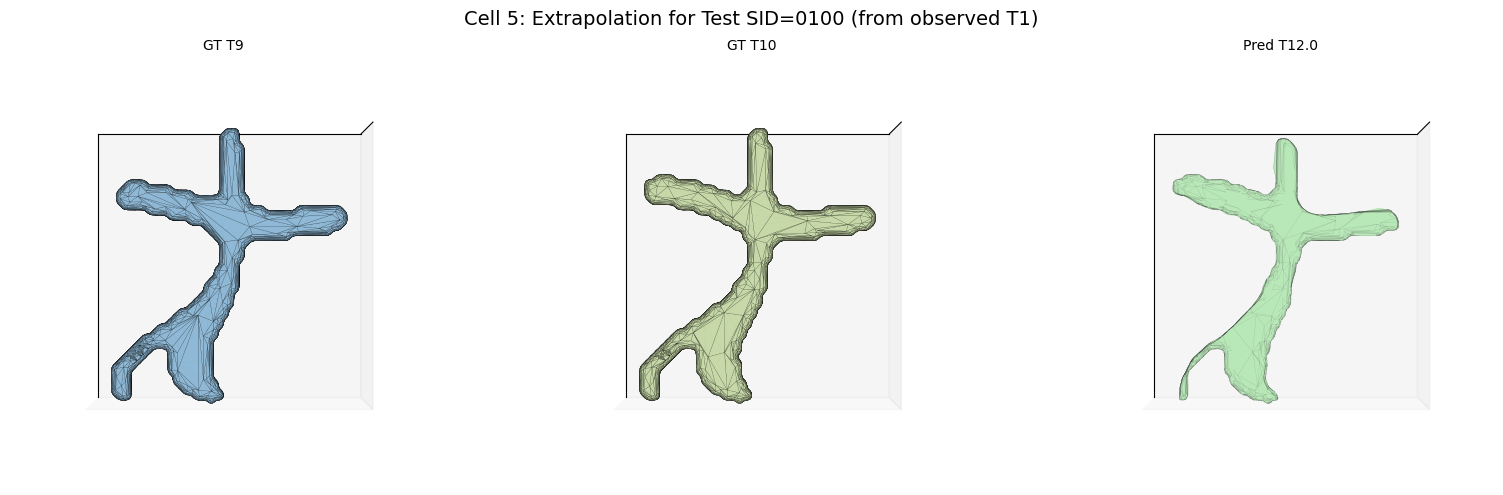

Extrapolation user time: 12.0
Extrapolation normalized time: 1.2222222222222223
Iso level used: 0.0


In [12]:
# Cell 5: Extrapolation. Predict at time 12 from observed time 1. Show GT time 9 and GT time 10.
if "TEST_ANCHOR_FROM_T1" not in globals() or "TEST_RECORDS" not in globals():
    raise RuntimeError("Run Cell 1 first.")

gt_t9_rec = record_by_user_time(TEST_RECORDS, 9)
gt_t10_rec = record_by_user_time(TEST_RECORDS, 10)

T_EXTRA_USER = 12.0
T_EXTRA_NORM = user_time_to_norm(T_EXTRA_USER, TEST_RECORDS, TEST_META)

# Extrapolation has no GT SDF; use latest GT timepoint for iso-level calibration.
latest_sdf = load_sdf_ram(gt_t10_rec)

pred_extra_mesh, _, iso_extra = mesh_from_anchor_time(
    TEST_ANCHOR_FROM_T1,
    float(T_EXTRA_NORM),
    sdf_data_for_iso=latest_sdf,
)

gt_mesh_t9 = load_trimesh(gt_t9_rec["gt_path"])
gt_mesh_t10 = load_trimesh(gt_t10_rec["gt_path"])

plot_three(
    gt_mesh_t9,
    "GT T9",
    gt_mesh_t10,
    "GT T10",
    pred_extra_mesh,
    f"Pred T{T_EXTRA_USER}",
    suptitle=f"Cell 5: Extrapolation for Test SID={TEST_SID} (from observed T1)",
)

print("Extrapolation user time:", T_EXTRA_USER)
print("Extrapolation normalized time:", T_EXTRA_NORM)
print("Iso level used:", iso_extra)

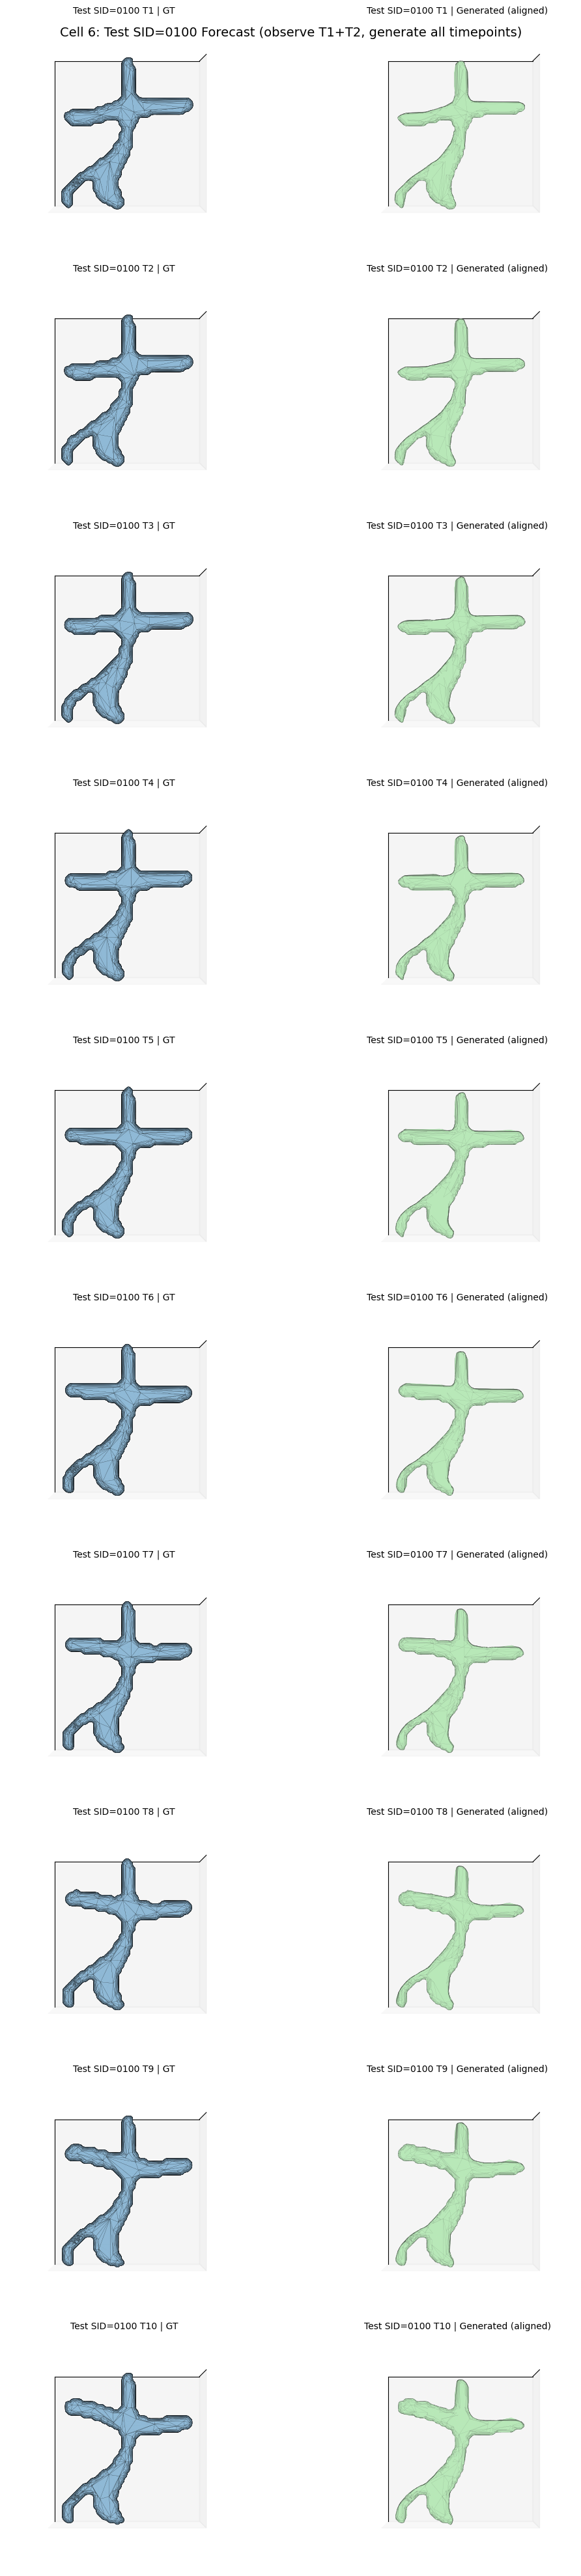

Test SID: 0100
Observed scans: starman3d__ds-output_random_noacc__sid-0100__tp-00__age-m006p40__scan-SimulatedData__Reconstruction__starman__subject_s100__tp_0 starman3d__ds-output_random_noacc__sid-0100__tp-01__age-m005p40__scan-SimulatedData__Reconstruction__starman__subject_s100__tp_1
Anchor optimization final loss: 0.001240245532244444
Iso per timepoint: {1: 0.0, 2: 0.0, 3: 0.0, 4: 0.0, 5: 0.0, 6: 0.0, 7: 0.0, 8: 0.0, 9: 0.0015, 10: 0.0015}


In [13]:
# Cell 6: Test subject two-observation forecast. Observe T1+T2, generate all 10 timepoints, show GT vs generated.
if "TEST_META" not in globals():
    raise RuntimeError("Run setup/helper cells first.")

# Reuse current test subject if already selected; otherwise pick by TARGET_TEST_SUBJECT_ID.
if "TEST_SID" not in globals() or "TEST_RECORDS" not in globals():
    TEST_SID = pick_subject(TEST_META, explicit_subject_id=TARGET_TEST_SUBJECT_ID, min_scans=10)
    TEST_RECORDS = TEST_META["subject_to_records"][TEST_SID]

TEST_RECORDS_T1T2 = sorted(TEST_RECORDS, key=lambda r: int(r["tp_user"]))

obs_rec_t1_2obs = record_by_user_time(TEST_RECORDS_T1T2, 1)
obs_rec_t2_2obs = record_by_user_time(TEST_RECORDS_T1T2, 2)

obs_sdf_t1_2obs = load_sdf_ram(obs_rec_t1_2obs)
obs_sdf_t2_2obs = load_sdf_ram(obs_rec_t2_2obs)

obs_list_t1_t2 = [
    {"samples": obs_sdf_t1_2obs, "time": float(obs_rec_t1_2obs["t_norm"])},
    {"samples": obs_sdf_t2_2obs, "time": float(obs_rec_t2_2obs["t_norm"])},
]

TEST_ANCHOR_FROM_T1_T2, TEST_ANCHOR_LOSS_HIST_T1_T2 = optimize_anchor_from_observations(
    decoder,
    flow_net,
    LATENT_SIZE,
    obs_list_t1_t2,
    clamp_dist=CLAMP_DIST,
    num_iterations=OBS_OPT_STEPS,
    num_samples=OBS_OPT_SAMPLES,
    lr=OBS_OPT_LR,
    init_std=OBS_INIT_STD,
    code_reg_lambda=OBS_CODE_REG,
    code_bound=CODE_BOUND,
)

rows_t1_t2 = []
iso_levels_t1_t2 = {}
for rec in TEST_RECORDS_T1T2:
    sdf_for_iso = load_sdf_ram(rec)
    pred_mesh, _, iso_val = mesh_from_anchor_time(
        TEST_ANCHOR_FROM_T1_T2,
        float(rec["t_norm"]),
        sdf_data_for_iso=sdf_for_iso,
    )
    gt_mesh = load_trimesh(rec["gt_path"])
    rows_t1_t2.append({
        "gt_mesh": gt_mesh,
        "pred_mesh": pred_mesh,
        "label": f"Test SID={TEST_SID} T{rec['tp_user']}",
    })
    iso_levels_t1_t2[int(rec["tp_user"])] = float(iso_val)

plot_rows_gt_pred(
    rows_t1_t2,
    suptitle=f"Cell 6: Test SID={TEST_SID} Forecast (observe T1+T2, generate all timepoints)",
    pred_color=PRED_LIGHT_GREEN,
)

print("Test SID:", TEST_SID)
print("Observed scans:", obs_rec_t1_2obs["name"], obs_rec_t2_2obs["name"])
print("Anchor optimization final loss:", TEST_ANCHOR_LOSS_HIST_T1_T2[-1] if TEST_ANCHOR_LOSS_HIST_T1_T2 else None)
print("Iso per timepoint:", iso_levels_t1_t2)


## Composed Flow (Repeated Composition)

These cells use explicit repeated composition of the flow map for generation.
They are appended and do not modify previous cells.


In [14]:
# Helpers for repeated composition (explicit step-wise transport).
COMPOSED_MAX_DT_VIS = float(SPECS.get("EvalTestMaxRolloutDt", 0.1))
if COMPOSED_MAX_DT_VIS <= 0.0:
    COMPOSED_MAX_DT_VIS = 0.1

def compose_latent_interval(z_start, t_start, t_end, max_dt=COMPOSED_MAX_DT_VIS):
    dt_total = float(t_end) - float(t_start)
    if abs(dt_total) <= 1e-12:
        return z_start

    step_lim = float(max_dt) if max_dt is not None else 0.1
    if step_lim <= 0.0:
        step_lim = abs(dt_total)

    n_steps = max(1, int(np.ceil(abs(dt_total) / step_lim)))
    step = dt_total / float(n_steps)

    z = z_start
    cur_t = float(t_start)
    for _ in range(n_steps):
        nxt_t = cur_t + step
        s = torch.full((z.shape[0], 1), cur_t, device=z.device, dtype=z.dtype)
        t = torch.full((z.shape[0], 1), nxt_t, device=z.device, dtype=z.dtype)
        z = apply_temporal_flow(flow_net, z, s, t)
        cur_t = nxt_t
    return z

def compose_latent_from_anchor(anchor, t_target_norm, max_dt=COMPOSED_MAX_DT_VIS):
    return compose_latent_interval(anchor, 0.0, float(t_target_norm), max_dt=max_dt)

def mesh_from_latent(z_t, sdf_data_for_iso=None):
    iso_level = 0.0
    if sdf_data_for_iso is not None:
        iso_level = choose_iso_level(
            decoder,
            z_t,
            sdf_data_for_iso,
            ISO_CANDIDATES,
            clamp_dist=CLAMP_DIST,
            holdout_samples=ISO_HOLDOUT_SAMPLES,
        )

    sdf_vals, voxel_origin, voxel_size = decode_sdf_grid(
        decoder,
        z_t,
        N=GRID_RES,
        max_batch=int(2 ** 18),
    )

    m = mesh_from_sdf_grid(
        sdf_vals,
        voxel_origin,
        voxel_size,
        iso_level=float(iso_level),
        smooth_sigma=float(SMOOTH_SIGMA),
        keep_largest=bool(KEEP_LARGEST_COMPONENT),
    )
    if m is None and float(iso_level) != 0.0:
        m = mesh_from_sdf_grid(
            sdf_vals,
            voxel_origin,
            voxel_size,
            iso_level=0.0,
            smooth_sigma=float(SMOOTH_SIGMA),
            keep_largest=bool(KEEP_LARGEST_COMPONENT),
        )
    if m is None:
        m = mesh_from_sdf_grid(
            sdf_vals,
            voxel_origin,
            voxel_size,
            iso_level=0.0,
            smooth_sigma=0.0,
            keep_largest=bool(KEEP_LARGEST_COMPONENT),
        )
    if m is None:
        raise RuntimeError("Mesh creation failed (composed)")

    return m, float(iso_level)

def mesh_from_anchor_time_composed(anchor, t_norm, sdf_data_for_iso=None, max_dt=COMPOSED_MAX_DT_VIS):
    z_t = compose_latent_from_anchor(anchor, float(t_norm), max_dt=max_dt)
    m, iso_level = mesh_from_latent(z_t, sdf_data_for_iso=sdf_data_for_iso)
    return m, z_t.detach(), float(iso_level)

def rollout_rows_composed(anchor, records, prefix_label, max_dt=COMPOSED_MAX_DT_VIS, pred_color=PRED_LIGHT_GREEN):
    recs = sorted(records, key=lambda r: int(r["tp_user"]))
    rows = []
    iso_levels = {}

    z_prev = anchor
    t_prev = 0.0

    for rec in recs:
        t_cur = float(rec["t_norm"])
        if t_cur < (t_prev - 1e-8):
            z_cur = compose_latent_from_anchor(anchor, t_cur, max_dt=max_dt)
        else:
            z_cur = compose_latent_interval(z_prev, t_prev, t_cur, max_dt=max_dt)

        sdf_for_iso = load_sdf_ram(rec)
        pred_mesh, iso_val = mesh_from_latent(z_cur, sdf_data_for_iso=sdf_for_iso)
        gt_mesh = load_trimesh(rec["gt_path"])

        rows.append({
            "gt_mesh": gt_mesh,
            "pred_mesh": pred_mesh,
            "label": f"{prefix_label} T{rec['tp_user']}",
        })
        iso_levels[int(rec["tp_user"])] = float(iso_val)

        z_prev = z_cur.detach()
        t_prev = t_cur

    plot_rows_gt_pred(
        rows,
        suptitle=f"{prefix_label} | repeated composition (max_dt={max_dt})",
        pred_color=pred_color,
    )
    return rows, iso_levels

print("Composed helper ready. max_dt=", COMPOSED_MAX_DT_VIS)


Composed helper ready. max_dt= 0.1


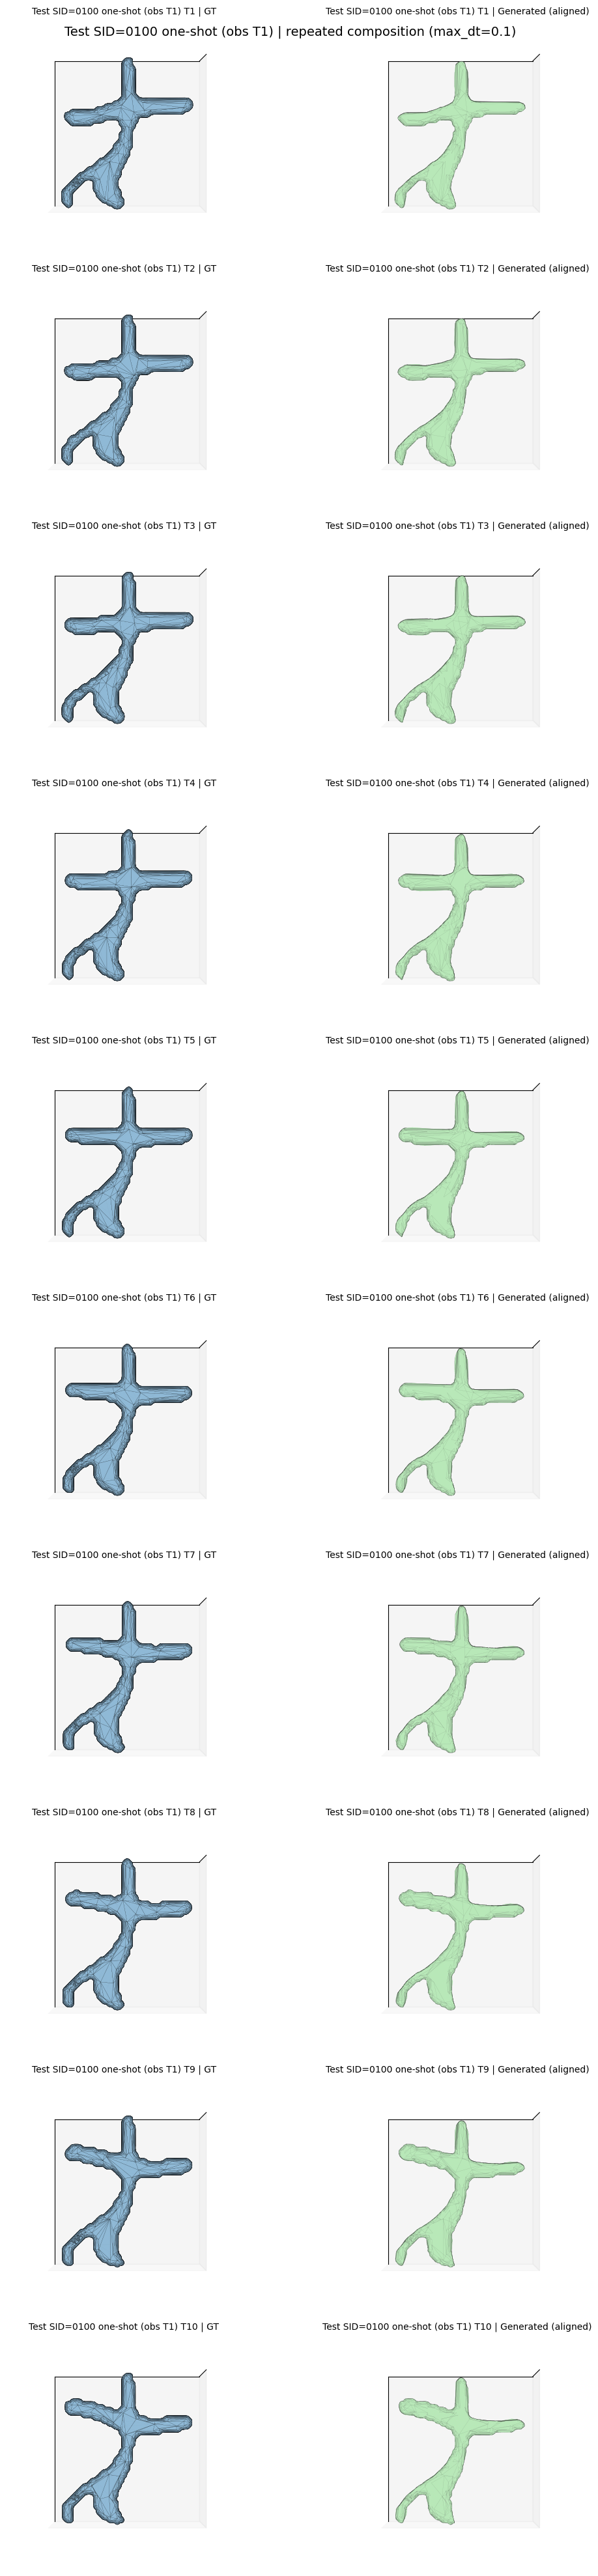

Test SID: 0100
Observed: starman3d__ds-output_random_noacc__sid-0100__tp-00__age-m006p40__scan-SimulatedData__Reconstruction__starman__subject_s100__tp_0
Anchor final loss: 0.0008427845314145088
Iso per timepoint: {1: 0.0, 2: 0.0, 3: 0.0, 4: 0.0, 5: 0.0, 6: 0.0, 7: 0.0, 8: 0.0, 9: 0.0, 10: 0.0}


In [15]:
# Composed generation: Test one-shot (observe T1, generate all timepoints).
TEST_SID_CMP = pick_subject(TEST_META, explicit_subject_id=TARGET_TEST_SUBJECT_ID, min_scans=10)
TEST_RECORDS_CMP = TEST_META["subject_to_records"][TEST_SID_CMP]
obs_test_t1_cmp = record_by_user_time(TEST_RECORDS_CMP, 1)

TEST_ANCHOR_CMP_T1, TEST_ANCHOR_CMP_T1_HIST = optimize_anchor_from_observations(
    decoder,
    flow_net,
    LATENT_SIZE,
    [{"samples": load_sdf_ram(obs_test_t1_cmp), "time": float(obs_test_t1_cmp["t_norm"])}],
    clamp_dist=CLAMP_DIST,
    num_iterations=OBS_OPT_STEPS,
    num_samples=OBS_OPT_SAMPLES,
    lr=OBS_OPT_LR,
    init_std=OBS_INIT_STD,
    code_reg_lambda=OBS_CODE_REG,
    code_bound=CODE_BOUND,
)

rows_test_cmp_t1, iso_test_cmp_t1 = rollout_rows_composed(
    TEST_ANCHOR_CMP_T1,
    TEST_RECORDS_CMP,
    prefix_label=f"Test SID={TEST_SID_CMP} one-shot (obs T1)",
    max_dt=COMPOSED_MAX_DT_VIS,
)

print("Test SID:", TEST_SID_CMP)
print("Observed:", obs_test_t1_cmp["name"])
print("Anchor final loss:", TEST_ANCHOR_CMP_T1_HIST[-1] if TEST_ANCHOR_CMP_T1_HIST else None)
print("Iso per timepoint:", iso_test_cmp_t1)


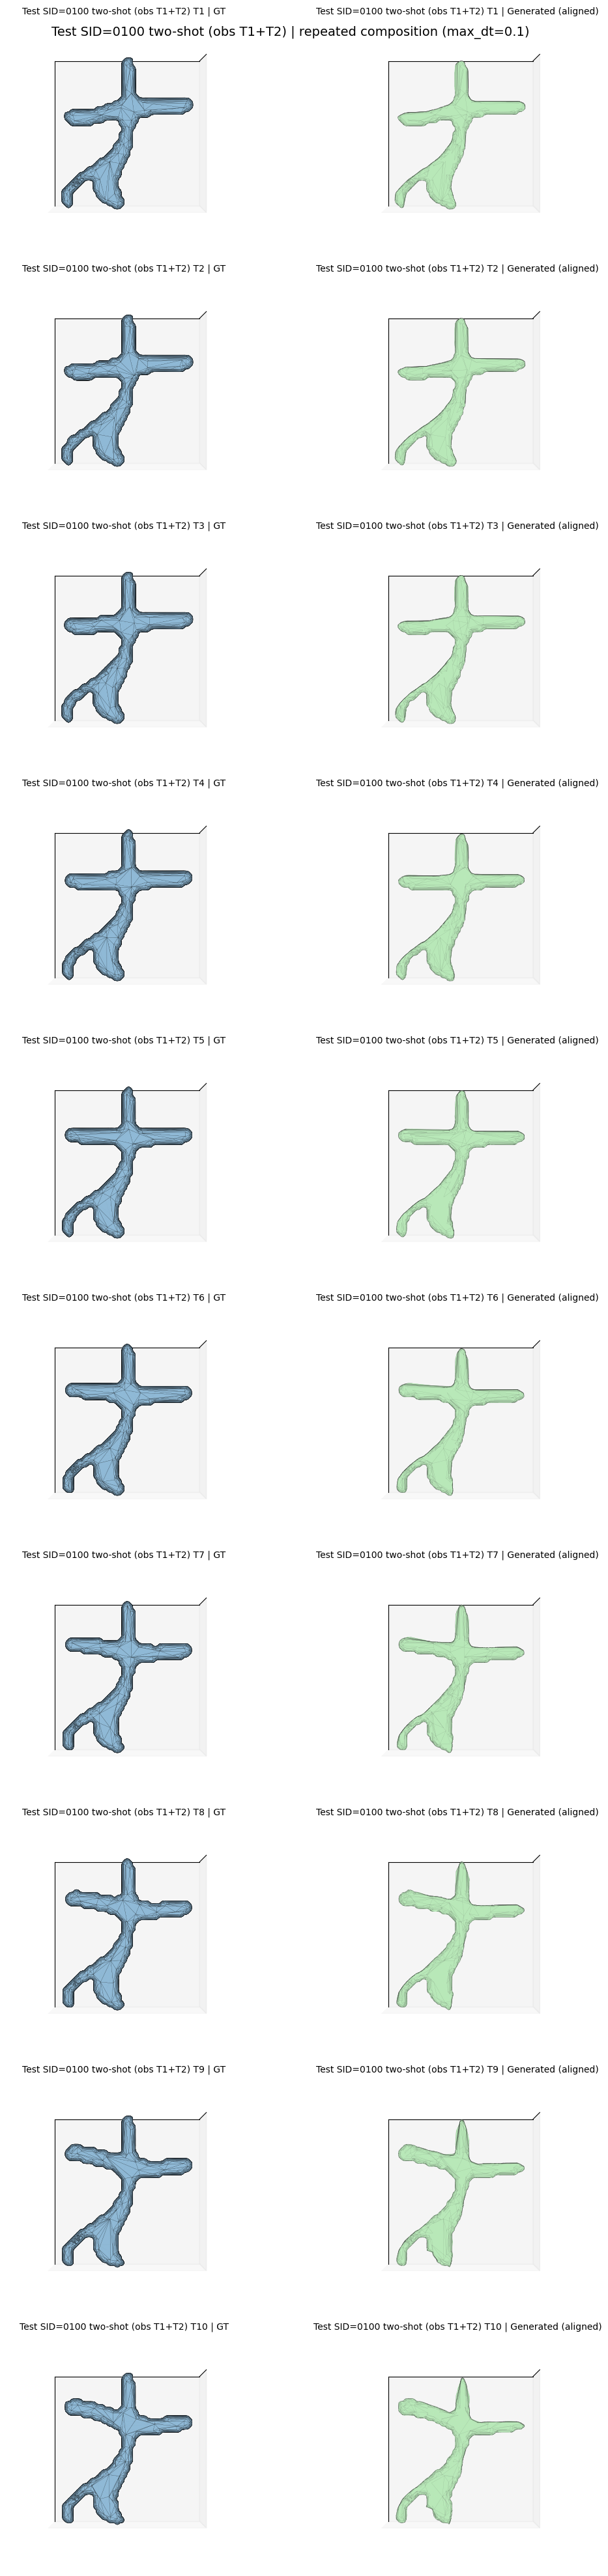

Observed: starman3d__ds-output_random_noacc__sid-0100__tp-00__age-m006p40__scan-SimulatedData__Reconstruction__starman__subject_s100__tp_0 starman3d__ds-output_random_noacc__sid-0100__tp-01__age-m005p40__scan-SimulatedData__Reconstruction__starman__subject_s100__tp_1
Anchor final loss: 0.0013082439545542002
Iso per timepoint: {1: 0.0, 2: 0.0, 3: 0.0, 4: 0.0, 5: 0.0, 6: 0.0, 7: 0.0, 8: 0.0015, 9: 0.0, 10: 0.0015}


In [16]:
# Composed generation: Test two-shot (observe T1+T2, generate all timepoints).
TEST_RECORDS_CMP_T12 = sorted(TEST_RECORDS_CMP, key=lambda r: int(r["tp_user"]))
obs_test_t1_2 = record_by_user_time(TEST_RECORDS_CMP_T12, 1)
obs_test_t2_2 = record_by_user_time(TEST_RECORDS_CMP_T12, 2)

TEST_ANCHOR_CMP_T1T2, TEST_ANCHOR_CMP_T1T2_HIST = optimize_anchor_from_observations(
    decoder,
    flow_net,
    LATENT_SIZE,
    [
        {"samples": load_sdf_ram(obs_test_t1_2), "time": float(obs_test_t1_2["t_norm"])},
        {"samples": load_sdf_ram(obs_test_t2_2), "time": float(obs_test_t2_2["t_norm"])},
    ],
    clamp_dist=CLAMP_DIST,
    num_iterations=OBS_OPT_STEPS,
    num_samples=OBS_OPT_SAMPLES,
    lr=OBS_OPT_LR,
    init_std=OBS_INIT_STD,
    code_reg_lambda=OBS_CODE_REG,
    code_bound=CODE_BOUND,
)

rows_test_cmp_t12, iso_test_cmp_t12 = rollout_rows_composed(
    TEST_ANCHOR_CMP_T1T2,
    TEST_RECORDS_CMP_T12,
    prefix_label=f"Test SID={TEST_SID_CMP} two-shot (obs T1+T2)",
    max_dt=COMPOSED_MAX_DT_VIS,
)

print("Observed:", obs_test_t1_2["name"], obs_test_t2_2["name"])
print("Anchor final loss:", TEST_ANCHOR_CMP_T1T2_HIST[-1] if TEST_ANCHOR_CMP_T1T2_HIST else None)
print("Iso per timepoint:", iso_test_cmp_t12)


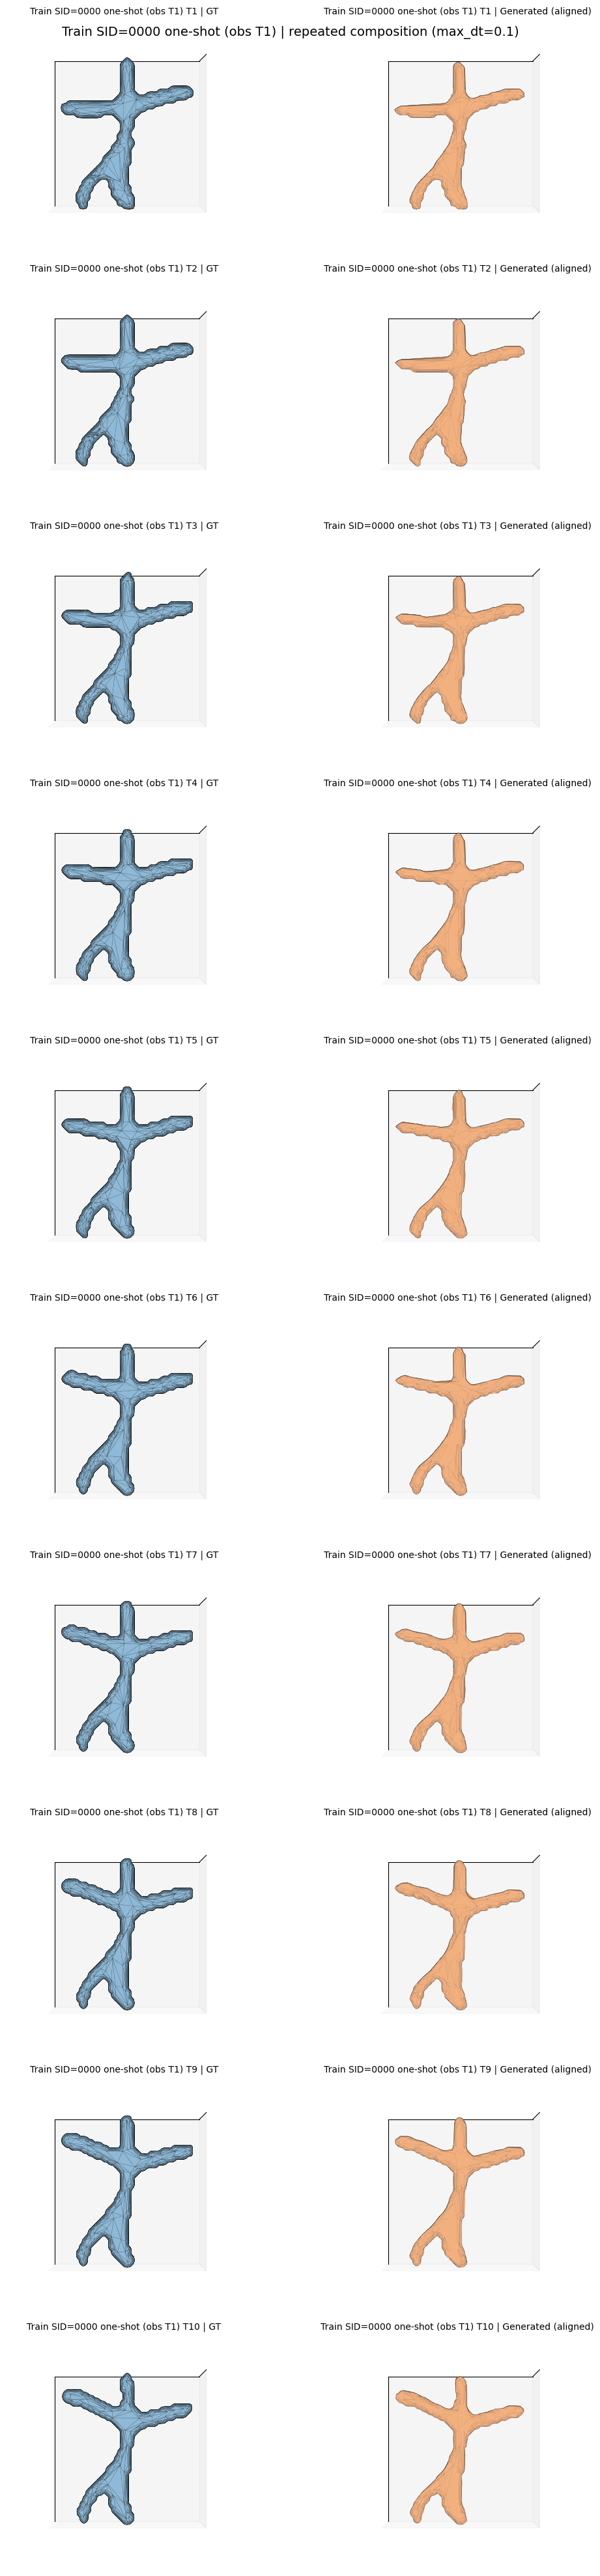

Train SID: 0000
Observed: starman3d__ds-output_random_noacc__sid-0000__tp-00__age-m004p29__scan-SimulatedData__Reconstruction__starman__subject_s0__tp_0
Anchor final loss: 0.0005821792292408645
Iso per timepoint: {1: 0.0, 2: 0.0, 3: 0.0, 4: 0.0, 5: 0.0, 6: 0.0, 7: 0.0, 8: 0.0, 9: 0.0, 10: 0.0}


In [17]:
# Composed generation: Train one-shot (observe T1, generate all timepoints).
TRAIN_SID_CMP = pick_subject(TRAIN_META, explicit_subject_id=TARGET_TRAIN_SUBJECT_ID, min_scans=10)
TRAIN_RECORDS_CMP = TRAIN_META["subject_to_records"][TRAIN_SID_CMP]
obs_train_t1_cmp = record_by_user_time(TRAIN_RECORDS_CMP, 1)

TRAIN_ANCHOR_CMP_T1, TRAIN_ANCHOR_CMP_T1_HIST = optimize_anchor_from_observations(
    decoder,
    flow_net,
    LATENT_SIZE,
    [{"samples": load_sdf_ram(obs_train_t1_cmp), "time": float(obs_train_t1_cmp["t_norm"])}],
    clamp_dist=CLAMP_DIST,
    num_iterations=OBS_OPT_STEPS,
    num_samples=OBS_OPT_SAMPLES,
    lr=OBS_OPT_LR,
    init_std=OBS_INIT_STD,
    code_reg_lambda=OBS_CODE_REG,
    code_bound=CODE_BOUND,
)

rows_train_cmp_t1, iso_train_cmp_t1 = rollout_rows_composed(
    TRAIN_ANCHOR_CMP_T1,
    TRAIN_RECORDS_CMP,
    prefix_label=f"Train SID={TRAIN_SID_CMP} one-shot (obs T1)",
    max_dt=COMPOSED_MAX_DT_VIS,
    pred_color="#f2b07f",
)

print("Train SID:", TRAIN_SID_CMP)
print("Observed:", obs_train_t1_cmp["name"])
print("Anchor final loss:", TRAIN_ANCHOR_CMP_T1_HIST[-1] if TRAIN_ANCHOR_CMP_T1_HIST else None)
print("Iso per timepoint:", iso_train_cmp_t1)


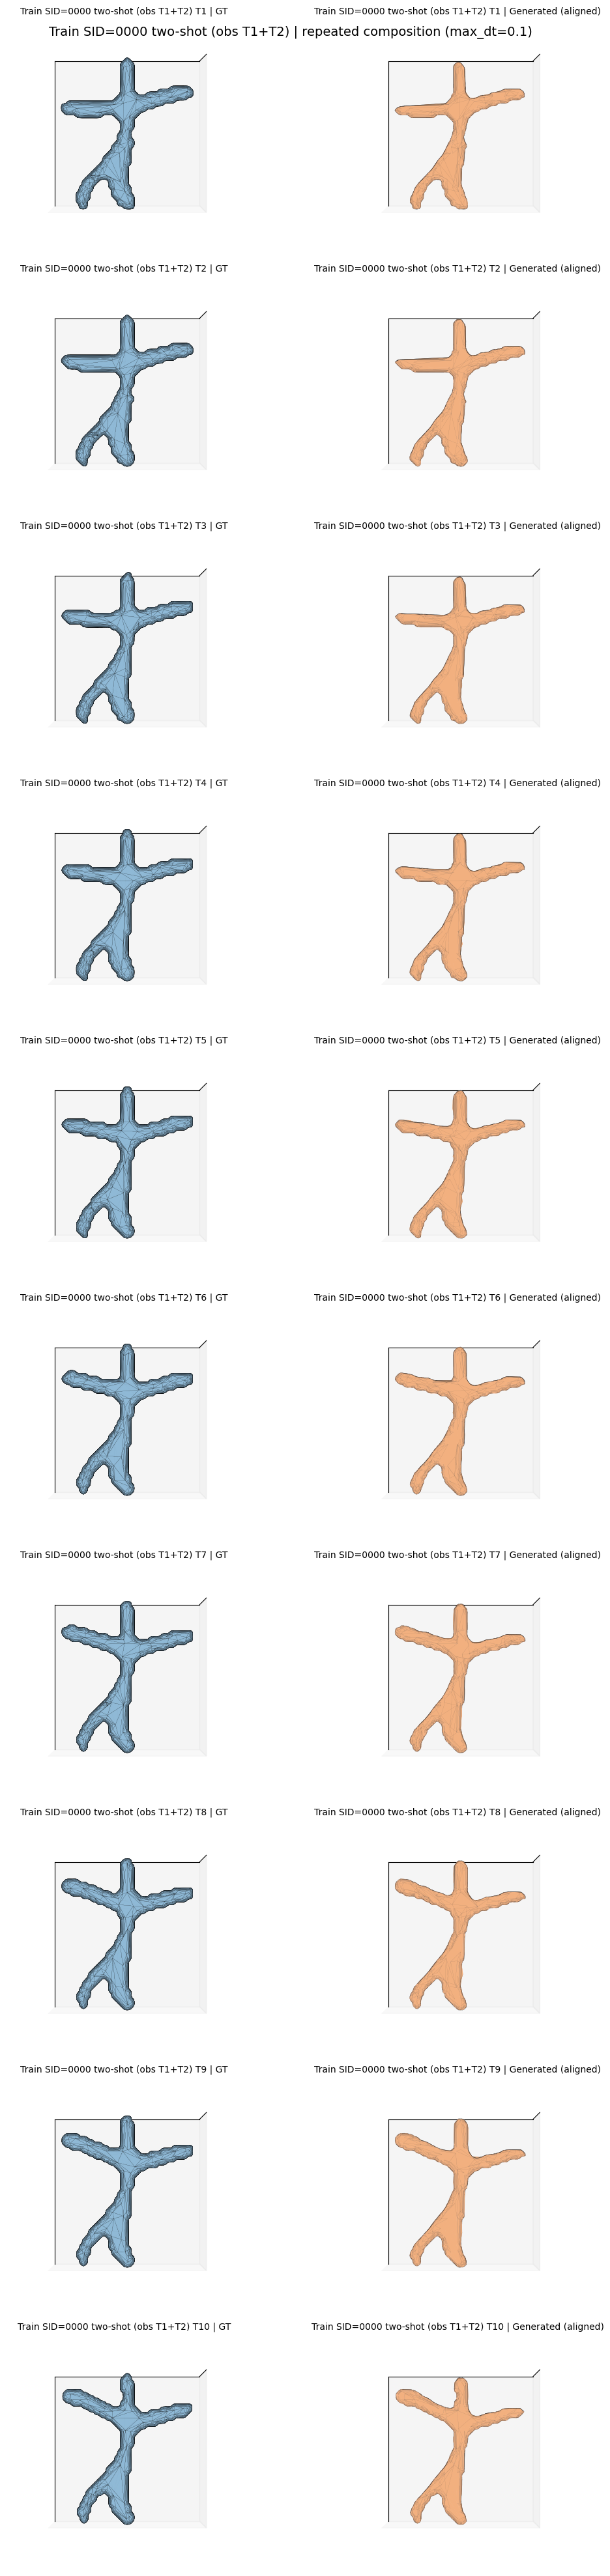

Observed: starman3d__ds-output_random_noacc__sid-0000__tp-00__age-m004p29__scan-SimulatedData__Reconstruction__starman__subject_s0__tp_0 starman3d__ds-output_random_noacc__sid-0000__tp-01__age-m003p24__scan-SimulatedData__Reconstruction__starman__subject_s0__tp_1
Anchor final loss: 0.0007040778291411698
Iso per timepoint: {1: 0.0, 2: 0.0, 3: 0.0, 4: 0.0, 5: 0.0, 6: 0.0, 7: 0.0, 8: 0.0, 9: 0.0, 10: 0.0}


In [18]:
# Composed generation: Train two-shot (observe T1+T2, generate all timepoints).
TRAIN_RECORDS_CMP_T12 = sorted(TRAIN_RECORDS_CMP, key=lambda r: int(r["tp_user"]))
obs_train_t1_2 = record_by_user_time(TRAIN_RECORDS_CMP_T12, 1)
obs_train_t2_2 = record_by_user_time(TRAIN_RECORDS_CMP_T12, 2)

TRAIN_ANCHOR_CMP_T1T2, TRAIN_ANCHOR_CMP_T1T2_HIST = optimize_anchor_from_observations(
    decoder,
    flow_net,
    LATENT_SIZE,
    [
        {"samples": load_sdf_ram(obs_train_t1_2), "time": float(obs_train_t1_2["t_norm"])},
        {"samples": load_sdf_ram(obs_train_t2_2), "time": float(obs_train_t2_2["t_norm"])},
    ],
    clamp_dist=CLAMP_DIST,
    num_iterations=OBS_OPT_STEPS,
    num_samples=OBS_OPT_SAMPLES,
    lr=OBS_OPT_LR,
    init_std=OBS_INIT_STD,
    code_reg_lambda=OBS_CODE_REG,
    code_bound=CODE_BOUND,
)

rows_train_cmp_t12, iso_train_cmp_t12 = rollout_rows_composed(
    TRAIN_ANCHOR_CMP_T1T2,
    TRAIN_RECORDS_CMP_T12,
    prefix_label=f"Train SID={TRAIN_SID_CMP} two-shot (obs T1+T2)",
    max_dt=COMPOSED_MAX_DT_VIS,
    pred_color="#f2b07f",
)

print("Observed:", obs_train_t1_2["name"], obs_train_t2_2["name"])
print("Anchor final loss:", TRAIN_ANCHOR_CMP_T1T2_HIST[-1] if TRAIN_ANCHOR_CMP_T1T2_HIST else None)
print("Iso per timepoint:", iso_train_cmp_t12)


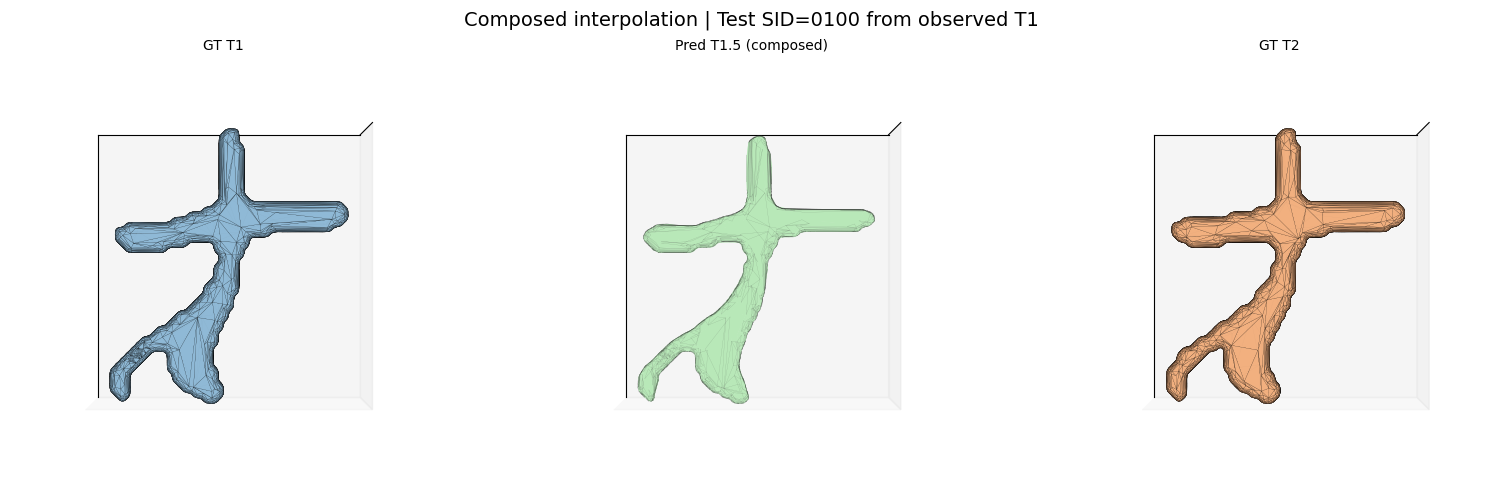

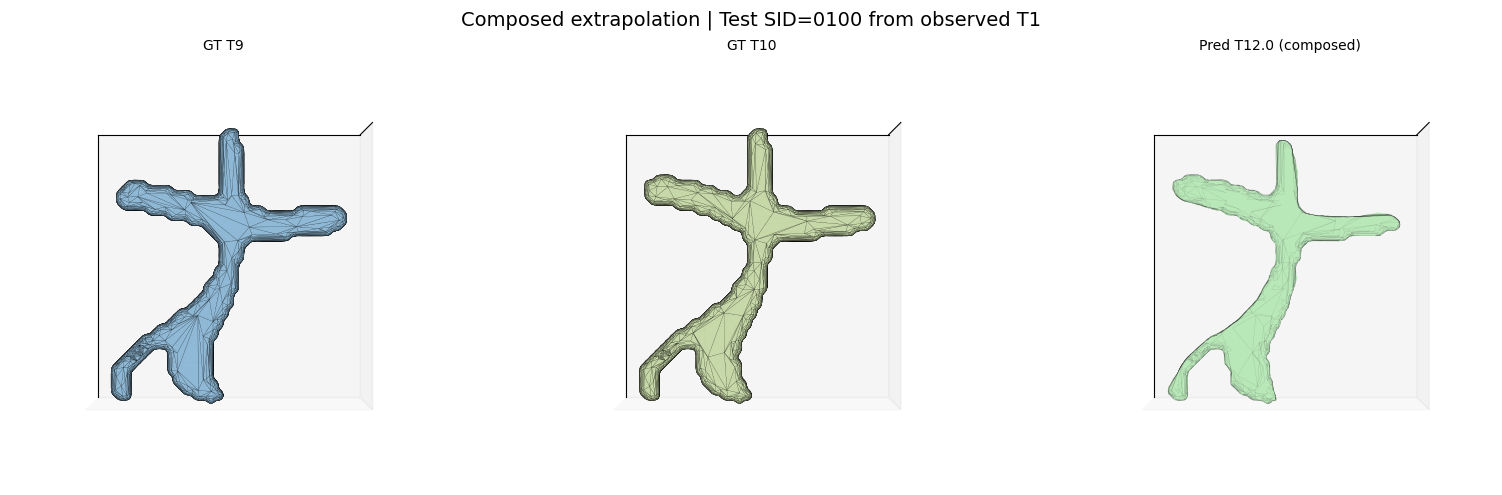

Test interpolation norm: 0.05555555555555555 iso: 0.0
Test extrapolation norm: 1.2222222222222223 iso: 0.0


In [19]:
# Composed interpolation/extrapolation: Test one-shot (from T1 anchor).
if "TEST_ANCHOR_CMP_T1" not in globals():
    raise RuntimeError("Run composed Test one-shot cell first.")

# Interpolation
test_gt_t1 = record_by_user_time(TEST_RECORDS_CMP, 1)
test_gt_t2 = record_by_user_time(TEST_RECORDS_CMP, 2)
T_INTERP_USER_CMP = 1.5
T_INTERP_NORM_CMP = user_time_to_norm(T_INTERP_USER_CMP, TEST_RECORDS_CMP, TEST_META)
nearest_interp = min(TEST_RECORDS_CMP, key=lambda r: abs(float(r["tp_user"]) - float(T_INTERP_USER_CMP)))
pred_interp_cmp, _, iso_interp_cmp = mesh_from_anchor_time_composed(
    TEST_ANCHOR_CMP_T1,
    float(T_INTERP_NORM_CMP),
    sdf_data_for_iso=load_sdf_ram(nearest_interp),
    max_dt=COMPOSED_MAX_DT_VIS,
)
plot_three(
    load_trimesh(test_gt_t1["gt_path"]),
    "GT T1",
    pred_interp_cmp,
    f"Pred T{T_INTERP_USER_CMP} (composed)",
    load_trimesh(test_gt_t2["gt_path"]),
    "GT T2",
    suptitle=f"Composed interpolation | Test SID={TEST_SID_CMP} from observed T1",
)

# Extrapolation
test_gt_t9 = record_by_user_time(TEST_RECORDS_CMP, 9)
test_gt_t10 = record_by_user_time(TEST_RECORDS_CMP, 10)
T_EXTRA_USER_CMP = 12.0
T_EXTRA_NORM_CMP = user_time_to_norm(T_EXTRA_USER_CMP, TEST_RECORDS_CMP, TEST_META)
pred_extra_cmp, _, iso_extra_cmp = mesh_from_anchor_time_composed(
    TEST_ANCHOR_CMP_T1,
    float(T_EXTRA_NORM_CMP),
    sdf_data_for_iso=load_sdf_ram(test_gt_t10),
    max_dt=COMPOSED_MAX_DT_VIS,
)
plot_three(
    load_trimesh(test_gt_t9["gt_path"]),
    "GT T9",
    load_trimesh(test_gt_t10["gt_path"]),
    "GT T10",
    pred_extra_cmp,
    f"Pred T{T_EXTRA_USER_CMP} (composed)",
    suptitle=f"Composed extrapolation | Test SID={TEST_SID_CMP} from observed T1",
)

print("Test interpolation norm:", T_INTERP_NORM_CMP, "iso:", iso_interp_cmp)
print("Test extrapolation norm:", T_EXTRA_NORM_CMP, "iso:", iso_extra_cmp)


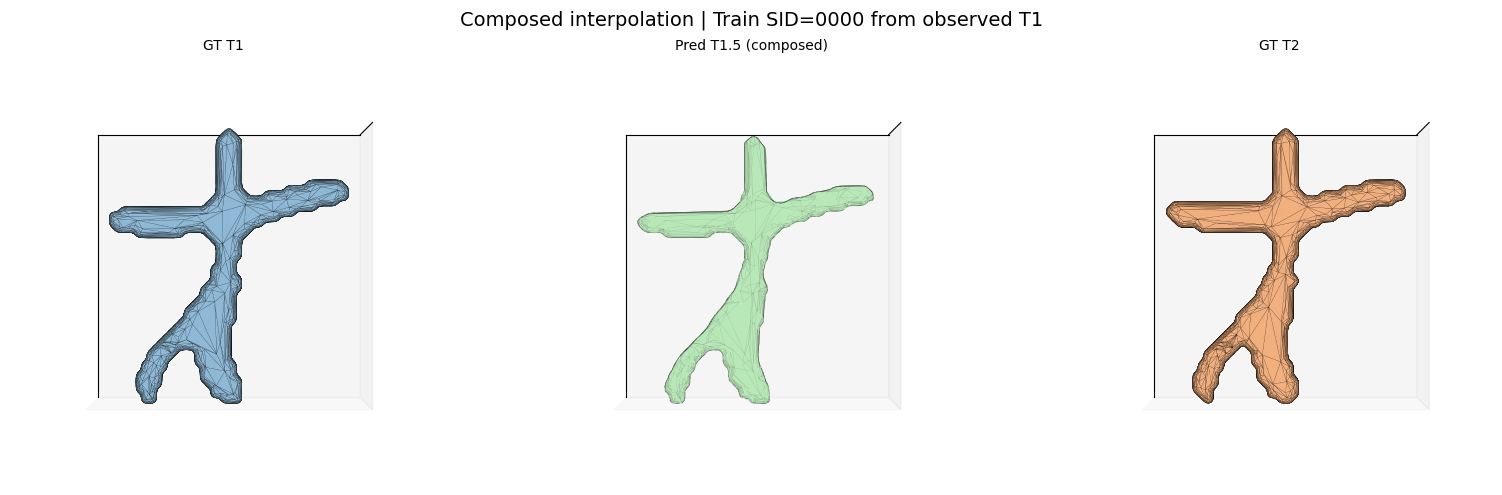

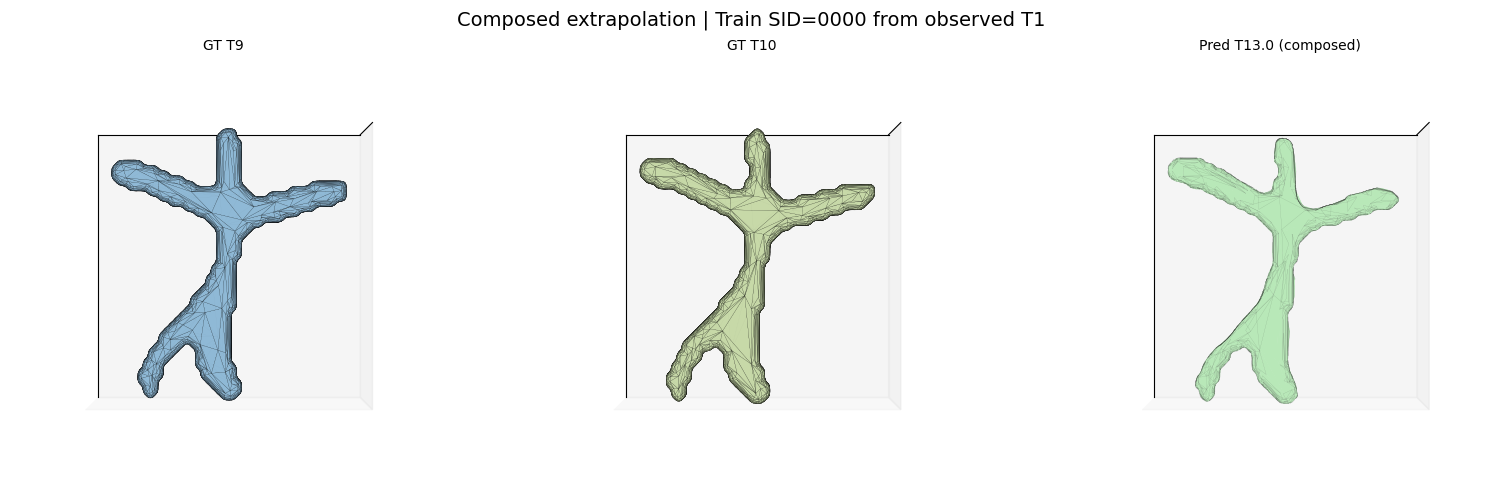

Train interpolation norm: 0.05555555555555555 iso: 0.0
Train extrapolation norm: 1.3333333333333333 iso: 0.0


In [20]:
# Composed interpolation/extrapolation: Train one-shot (from T1 anchor).
if "TRAIN_ANCHOR_CMP_T1" not in globals():
    raise RuntimeError("Run composed Train one-shot cell first.")

# Interpolation
train_gt_t1_cmp = record_by_user_time(TRAIN_RECORDS_CMP, 1)
train_gt_t2_cmp = record_by_user_time(TRAIN_RECORDS_CMP, 2)
TRAIN_INTERP_USER_CMP = 1.5
TRAIN_INTERP_NORM_CMP = user_time_to_norm(TRAIN_INTERP_USER_CMP, TRAIN_RECORDS_CMP, TRAIN_META)
nearest_train_interp = min(TRAIN_RECORDS_CMP, key=lambda r: abs(float(r["tp_user"]) - float(TRAIN_INTERP_USER_CMP)))
pred_train_interp_cmp, _, iso_train_interp_cmp = mesh_from_anchor_time_composed(
    TRAIN_ANCHOR_CMP_T1,
    float(TRAIN_INTERP_NORM_CMP),
    sdf_data_for_iso=load_sdf_ram(nearest_train_interp),
    max_dt=COMPOSED_MAX_DT_VIS,
)
plot_three(
    load_trimesh(train_gt_t1_cmp["gt_path"]),
    "GT T1",
    pred_train_interp_cmp,
    f"Pred T{TRAIN_INTERP_USER_CMP} (composed)",
    load_trimesh(train_gt_t2_cmp["gt_path"]),
    "GT T2",
    suptitle=f"Composed interpolation | Train SID={TRAIN_SID_CMP} from observed T1",
)

# Extrapolation
train_gt_t9_cmp = record_by_user_time(TRAIN_RECORDS_CMP, 9)
train_gt_t10_cmp = record_by_user_time(TRAIN_RECORDS_CMP, 10)
TRAIN_EXTRA_USER_CMP = 13.0
TRAIN_EXTRA_NORM_CMP = user_time_to_norm(TRAIN_EXTRA_USER_CMP, TRAIN_RECORDS_CMP, TRAIN_META)
pred_train_extra_cmp, _, iso_train_extra_cmp = mesh_from_anchor_time_composed(
    TRAIN_ANCHOR_CMP_T1,
    float(TRAIN_EXTRA_NORM_CMP),
    sdf_data_for_iso=load_sdf_ram(train_gt_t10_cmp),
    max_dt=COMPOSED_MAX_DT_VIS,
)
plot_three(
    load_trimesh(train_gt_t9_cmp["gt_path"]),
    "GT T9",
    load_trimesh(train_gt_t10_cmp["gt_path"]),
    "GT T10",
    pred_train_extra_cmp,
    f"Pred T{TRAIN_EXTRA_USER_CMP} (composed)",
    suptitle=f"Composed extrapolation | Train SID={TRAIN_SID_CMP} from observed T1",
)

print("Train interpolation norm:", TRAIN_INTERP_NORM_CMP, "iso:", iso_train_interp_cmp)
print("Train extrapolation norm:", TRAIN_EXTRA_NORM_CMP, "iso:", iso_train_extra_cmp)
